# Hybrid Multimodal Product Search

Dense visual-text embeddings and SPLADE sparse representations support hybrid retrieval, cross-encoder reranking, pooled relevance evaluation, and grounded structured answers. Optional QLoRA experiments adapt the answer model.

Run from this module directory after installing the retrieval dependencies and restoring the inputs described in `data/README.md`. Recorded plots and tables come from the supplied notebook; they have not been rerun during repository preparation.


In [ ]:
from pathlib import Path
import os

root = Path.cwd()
if not (root / "pyproject.toml").exists():
    root = root / "multimodal-product-search"
if not (root / "src").is_dir():
    raise FileNotFoundError("Open the notebook from the repository or multimodal-product-search directory.")
os.chdir(root)
PROJECT_ROOT = str(Path.cwd())
print("Project:", PROJECT_ROOT)


# Multimodal and Sparse Indexing

Each product receives one dense vector from combined text and image input and one SPLADE sparse representation. FAISS and SciPy CSR indexes share a product-ID mapping. Supply the catalog and images under `data/` before continuing.


## 0. Install dependencies

In [ ]:
# Install dependencies in your active notebook environment when needed.
INSTALL_DEPENDENCIES = False
if INSTALL_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", ".[retrieval]"])


In [ ]:
import sys
import numpy as np
import pandas as pd
import pyarrow as pa

print("Python :", sys.version)
print("NumPy  :", np.__version__)
print("pandas :", pd.__version__)
print("PyArrow:", pa.__version__)

# Directly test the actual project parquet file
test_df = pd.read_parquet(
    "data/catalog_subset.parquet"
)

print("Parquet test: OK")
print("Rows:", len(test_df))
print("Columns:", list(test_df.columns))

## Catalog and image inputs

See `data/README.md` for the expected catalog, queries, and image paths.


In [ ]:
import os, json, time, glob, shutil, zipfile
import numpy as np
import pandas as pd

# Use the catalog and images restored under data/. Colab's /content disk is used for fast image I/O.
PROJECT_DIR = os.path.abspath(os.getcwd())
DRIVE_INPUT = os.path.join(PROJECT_DIR, "data")
WORK = os.path.join(PROJECT_DIR, ".indexing_input")
os.makedirs(WORK, exist_ok=True)

# ----- output locations -----
EMB_DIR    = "artifacts/embeddings"
INDEX_DIR  = "artifacts/index"
REPORT_DIR = "reports"
for d in (EMB_DIR, INDEX_DIR, REPORT_DIR):
    os.makedirs(d, exist_ok=True)

DENSE_NPY    = f"{EMB_DIR}/product_dense.npy"
SPARSE_JSONL = f"{EMB_DIR}/product_sparse.jsonl"
IDS_TXT      = f"{EMB_DIR}/product_ids.txt"
DENSE_INDEX  = f"{INDEX_DIR}/dense_index.faiss"
SPARSE_INDEX = f"{INDEX_DIR}/sparse_index.npz"
MANIFEST     = f"{INDEX_DIR}/index_manifest.json"
SUMMARY      = f"{REPORT_DIR}/indexing_summary.md"

# Encoders required by the retrieval design.
DENSE_MODEL  = "Qwen/Qwen3-VL-Embedding-2B"
SPARSE_MODEL = "prithivida/Splade_PP_en_v2"

# Conservative Colab defaults. Reduce dense_batch_size to 1 if VRAM is tight.
DENSE_BATCH_SIZE  = 2
DENSE_CHUNK       = 64
SPARSE_BATCH_SIZE = 8
SPARSE_MAX_LEN    = 256
SPARSE_TOP_N      = 256
DENSE_NORMALIZE   = True

print("Project input:", DRIVE_INPUT)
print("dense:", DENSE_MODEL, "| sparse:", SPARSE_MODEL)
print("dense batch/chunk:", DENSE_BATCH_SIZE, DENSE_CHUNK)
print("sparse batch/max_len/top_n:", SPARSE_BATCH_SIZE, SPARSE_MAX_LEN, SPARSE_TOP_N)


In [ ]:
# Stage the bundled catalog/images onto local disk and verify every product image.
os.makedirs(WORK, exist_ok=True)
zips = sorted(glob.glob(os.path.join(DRIVE_INPUT, "*.zip")))
for z in zips:
    local_zip = os.path.join(WORK, os.path.basename(z))
    if not os.path.exists(local_zip) or os.path.getsize(local_zip) != os.path.getsize(z):
        print("copying zip:", z)
        shutil.copyfile(z, local_zip)
    print("unzipping", os.path.basename(z), "...")
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(WORK)
if not zips:
    print("no .zip in project data folder; using images already extracted in the project tree")


def _find(name, *roots):
    """Find a file by name directly under, or anywhere within, the given roots."""
    for root in roots:
        direct = os.path.join(root, name)
        if os.path.exists(direct):
            return direct
        hits = glob.glob(os.path.join(root, "**", name), recursive=True)
        if hits:
            return sorted(hits)[0]
    return None

src_parquet = _find("catalog_subset.parquet", DRIVE_INPUT, WORK)
assert src_parquet, "catalog_subset.parquet not found in the data folder."
CATALOG_PATH = os.path.join(WORK, "catalog_subset.parquet")
if os.path.abspath(src_parquet) != os.path.abspath(CATALOG_PATH):
    shutil.copyfile(src_parquet, CATALOG_PATH)
print("catalog:", src_parquet)

# Build a basename -> path index over staged images.
IMAGES_BASE = WORK if zips else PROJECT_DIR
print("indexing image files under", IMAGES_BASE, "...")
IMAGE_INDEX = {}
for root, _, files in os.walk(IMAGES_BASE):
    for fn in files:
        if fn.lower().endswith((".jpg", ".jpeg", ".png")):
            IMAGE_INDEX.setdefault(fn, os.path.join(root, fn))
print("images indexed:", len(IMAGE_INDEX))


def resolve_image(path):
    for base in (IMAGES_BASE, PROJECT_DIR):
        cand = os.path.join(base, str(path))
        if os.path.exists(cand):
            return cand
    if os.path.isabs(str(path)) and os.path.exists(str(path)):
        return str(path)
    return IMAGE_INDEX.get(os.path.basename(str(path)))

catalog = pd.read_parquet(CATALOG_PATH)
REQUIRED = ["product_id", "title", "product_text", "image_path"]
missing = [c for c in REQUIRED if c not in catalog.columns]
assert not missing, f"catalog missing required columns: {missing}"
print(f"catalog rows: {len(catalog)}")

catalog["resolved_image"] = catalog["image_path"].map(resolve_image)
n_missing_img = int(catalog["resolved_image"].isna().sum())
print(f"images resolved: {len(catalog) - n_missing_img}/{len(catalog)} (missing: {n_missing_img})")
assert n_missing_img == 0, "Some images not found - check product_images.zip contents."

# Stable ordering: product_ids.txt line i <-> product_dense.npy row i.
product_ids   = catalog["product_id"].astype(str).tolist()
product_texts = catalog["product_text"].fillna("").astype(str).tolist()
image_paths   = catalog["resolved_image"].astype(str).tolist()


## 2. Dense multimodal embeddings

The dense vector is produced **directly** from the combined
`{"text": product_text, "image": image_path}` object via `encode_document`
(falling back to `encode`). We never encode text and image separately and merge
them. Embeddings are **checkpointed every `DENSE_CHUNK` products** so a Colab
disconnect can resume instead of restarting, and the final `.npy` is cached so
later retrieval runs never recompute it.

In [ ]:
import torch
from sentence_transformers import SentenceTransformer

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GPU_NAME = torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu"
print("device:", DEVICE, "|", GPU_NAME)

# Load with float16 on CUDA when supported, with a safe fallback.
DENSE_LOAD_CFG = "default dtype"
if DEVICE == "cuda":
    try:
        dense_model = SentenceTransformer(
            DENSE_MODEL,
            device=DEVICE,
            model_kwargs={"torch_dtype": torch.float16},
        )
        DENSE_LOAD_CFG = "float16 on CUDA"
    except Exception as exc:
        print("float16 load failed; retrying default dtype:", exc)
        dense_model = SentenceTransformer(DENSE_MODEL, device=DEVICE)
else:
    dense_model = SentenceTransformer(DENSE_MODEL, device=DEVICE)

print("loaded:", DENSE_MODEL, "|", DENSE_LOAD_CFG)


In [ ]:
def l2_normalize(mat):
    mat = np.asarray(mat, dtype=np.float32)
    if mat.ndim == 1:
        mat = mat.reshape(1, -1)
    norms = np.linalg.norm(mat, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (mat / norms).astype(np.float32)


def encode_documents(inputs, batch_size):
    """Encode each combined {text,image} dictionary directly into one vector."""
    kw = dict(
        batch_size=batch_size,
        show_progress_bar=False,
        convert_to_numpy=True,
        normalize_embeddings=DENSE_NORMALIZE,
    )
    fn = getattr(dense_model, "encode_document", None) or dense_model.encode
    arr = np.asarray(fn(inputs, **kw), dtype=np.float32)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)
    if DENSE_NORMALIZE:
        arr = l2_normalize(arr)
    if arr.shape[0] != len(inputs):
        raise ValueError(f"dense encoder returned {arr.shape[0]} rows for {len(inputs)} inputs")
    return arr

# Critical policy: one multimodal dictionary per product; no manual vector mixing.
product_inputs = [
    {"text": t, "image": p}
    for t, p in zip(product_texts, image_paths)
]

_smoke = encode_documents(product_inputs[:2], batch_size=min(2, DENSE_BATCH_SIZE))
print("smoke embedding shape:", _smoke.shape)
DENSE_DIM = int(_smoke.shape[1])
print("dense dimension:", DENSE_DIM)


In [ ]:
from tqdm.auto import tqdm


def build_dense(inputs, out_npy, ids_txt, chunk, batch_size):
    # Cache: never recompute completed embeddings on later runs.
    if os.path.exists(out_npy) and os.path.exists(ids_txt):
        ids_cached = open(ids_txt, encoding="utf-8").read().splitlines()
        dense_cached = np.load(out_npy)
        if ids_cached == product_ids and dense_cached.shape[0] == len(inputs):
            print("dense cache hit -> loading", out_npy)
            return dense_cached.astype(np.float32)
        print("dense cache is stale; rebuilding")

    part_npy, part_cnt = out_npy + ".part.npy", out_npy + ".part.cnt"
    parts, done = [], 0
    if os.path.exists(part_npy) and os.path.exists(part_cnt):
        partial = np.load(part_npy)
        done = int(open(part_cnt, encoding="utf-8").read().strip())
        if partial.shape[0] == done and done <= len(inputs):
            parts.append(partial.astype(np.float32))
            print(f"resuming dense from {done}/{len(inputs)}")
        else:
            print("discarding inconsistent dense checkpoint")
            done = 0

    for s in tqdm(range(done, len(inputs), chunk), desc="dense products"):
        batch_inputs = inputs[s:s + chunk]
        chunk_vecs = encode_documents(batch_inputs, batch_size=batch_size)
        if DENSE_NORMALIZE:
            chunk_vecs = l2_normalize(chunk_vecs)
        parts.append(chunk_vecs.astype(np.float32))
        partial = np.vstack(parts).astype(np.float32)
        np.save(part_npy, partial)
        with open(part_cnt, "w", encoding="utf-8") as f:
            f.write(str(s + len(batch_inputs)))

    dense = np.vstack(parts).astype(np.float32) if parts else np.empty((0, 0), dtype=np.float32)
    if dense.shape[0] != len(inputs):
        raise ValueError(f"expected {len(inputs)} dense vectors, got {dense.shape[0]}")
    if DENSE_NORMALIZE:
        dense = l2_normalize(dense)
    np.save(out_npy, dense)
    with open(ids_txt, "w", encoding="utf-8") as f:
        f.write("\n".join(product_ids) + "\n")
    for p in (part_npy, part_cnt):
        if os.path.exists(p):
            os.remove(p)
    return dense


t0 = time.time()
product_dense = build_dense(
    product_inputs, DENSE_NPY, IDS_TXT, DENSE_CHUNK, DENSE_BATCH_SIZE
)
DENSE_MINUTES = (time.time() - t0) / 60
print("dense matrix:", product_dense.shape, "| minutes:", round(DENSE_MINUTES, 1))

assert product_dense.shape[0] == len(catalog), "one dense vector per product"
DENSE_DIM = int(product_dense.shape[1])
_norms = np.linalg.norm(product_dense, axis=1)
print("norm mean/min/max: %.4f / %.4f / %.4f" %
      (_norms.mean(), _norms.min(), _norms.max()))


## 3. Sparse SPLADE++ embeddings

SPLADE weight per vocab term = `max_t log(1 + relu(logits_t))` over the
sequence (attention-masked). We keep the **top-`SPARSE_TOP_N`** non-zero dims
per product and store them as `{product_id, indices, values}` — never a dense
30k array.

In [ ]:
from transformers import AutoTokenizer, AutoModelForMaskedLM

sp_tokenizer = AutoTokenizer.from_pretrained(SPARSE_MODEL)
sp_model = AutoModelForMaskedLM.from_pretrained(SPARSE_MODEL).to(DEVICE).eval()
VOCAB_SIZE = int(sp_model.config.vocab_size)
print("loaded sparse model:", SPARSE_MODEL, "| vocab:", VOCAB_SIZE)


@torch.no_grad()
def splade_encode_batch(texts, top_n):
    enc = sp_tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=SPARSE_MAX_LEN,
        return_tensors="pt",
    ).to(DEVICE)
    logits = sp_model(**enc).logits
    weights = torch.log1p(torch.relu(logits))
    weights = weights * enc["attention_mask"].unsqueeze(-1)
    pooled = torch.max(weights, dim=1).values

    out = []
    for row in pooled:
        nz = torch.nonzero(row > 0, as_tuple=False).squeeze(-1)
        if nz.numel() == 0:
            out.append((np.empty(0, dtype=np.int32), np.empty(0, dtype=np.float32)))
            continue
        vals = row[nz]
        k = min(int(top_n), int(vals.numel()))
        top_vals, order = torch.topk(vals, k=k, largest=True, sorted=True)
        top_idx = nz[order]
        out.append((
            top_idx.detach().cpu().numpy().astype(np.int32),
            top_vals.detach().cpu().numpy().astype(np.float32),
        ))
    return out


In [ ]:
import scipy.sparse as sp


def build_sparse(texts, jsonl_path, npz_path, batch_size, top_n):
    if os.path.exists(jsonl_path) and os.path.exists(npz_path):
        print("sparse cache hit -> loading", npz_path)
        return sp.load_npz(npz_path), None

    rows, cols, data, nnz_counts, failures = [], [], [], [], 0
    with open(jsonl_path, "w", encoding="utf-8") as fout:
        for s in tqdm(range(0, len(texts), batch_size), desc="sparse products"):
            batch = texts[s:s + batch_size]
            try:
                encoded = splade_encode_batch(batch, top_n)
            except Exception as e:
                print("sparse batch failed at", s, ":", e)
                failures += len(batch)
                for j in range(len(batch)):
                    fout.write(json.dumps({
                        "product_id": product_ids[s + j],
                        "indices": [],
                        "values": [],
                        "error": str(e),
                    }) + "\n")
                continue

            for j, (idx, val) in enumerate(encoded):
                i = s + j
                idx_list = [int(x) for x in idx.tolist()]
                val_list = [float(x) for x in val.tolist()]
                fout.write(json.dumps({
                    "product_id": product_ids[i],
                    "indices": idx_list,
                    "values": val_list,
                }) + "\n")
                rows.extend([i] * len(idx_list))
                cols.extend(idx_list)
                data.extend(val_list)
                nnz_counts.append(len(idx_list))

    matrix = sp.csr_matrix(
        (np.asarray(data, dtype=np.float32),
         (np.asarray(rows, dtype=np.int64), np.asarray(cols, dtype=np.int64))),
        shape=(len(texts), VOCAB_SIZE),
        dtype=np.float32,
    )
    sp.save_npz(npz_path, matrix)
    stats = {
        "avg_nnz": float(np.mean(nnz_counts)) if nnz_counts else 0.0,
        "min_nnz": int(np.min(nnz_counts)) if nnz_counts else 0,
        "max_nnz": int(np.max(nnz_counts)) if nnz_counts else 0,
        "failures": failures,
    }
    return matrix, stats


product_sparse, SPARSE_STATS = build_sparse(
    product_texts, SPARSE_JSONL, SPARSE_INDEX, SPARSE_BATCH_SIZE, SPARSE_TOP_N
)
if SPARSE_STATS is None:
    nnz = product_sparse.getnnz(axis=1)
    SPARSE_STATS = {
        "avg_nnz": float(nnz.mean()),
        "min_nnz": int(nnz.min()),
        "max_nnz": int(nnz.max()),
        "failures": 0,
    }
print("sparse matrix:", product_sparse.shape, "| stats:", SPARSE_STATS)
assert 0 < SPARSE_STATS["avg_nnz"] < VOCAB_SIZE, "avg nnz must be >0 and < vocab"


## 4. Build indexes — Option B: FAISS dense + CSR sparse + manifest

In [ ]:
import faiss

# Dense: inner product over L2-normalized vectors == cosine similarity.
dense_index = faiss.IndexFlatIP(DENSE_DIM)
dense_index.add(np.ascontiguousarray(product_dense, dtype=np.float32))
faiss.write_index(dense_index, DENSE_INDEX)
print("dense index:", dense_index.ntotal, "vectors, dim", DENSE_DIM)

# Sparse index is already saved as CSR .npz. Search = sparse dot product.
def sparse_search(query_indices, query_values, top_k=10):
    if query_indices is None or len(query_indices) == 0:
        return []
    q = np.zeros(product_sparse.shape[1], dtype=np.float32)
    q[np.asarray(query_indices, dtype=np.int64)] = np.asarray(query_values, dtype=np.float32)
    scores = np.asarray(product_sparse.dot(q)).ravel()
    k = min(int(top_k), len(scores))
    if k <= 0:
        return []
    if k == len(scores):
        top = np.argsort(-scores)
    else:
        top = np.argpartition(-scores, k - 1)[:k]
        top = top[np.argsort(-scores[top])]
    return [(int(i), float(scores[i])) for i in top]


def dense_search(query_vec, top_k=10):
    q = np.asarray(query_vec, dtype=np.float32).reshape(1, -1)
    q = l2_normalize(q)
    scores, idx = dense_index.search(np.ascontiguousarray(q), min(int(top_k), dense_index.ntotal))
    return [(int(i), float(s)) for i, s in zip(idx[0], scores[0]) if int(i) >= 0]


In [ ]:
manifest = {
    "num_products": int(len(catalog)),
    "dense_model": DENSE_MODEL,
    "dense_input_format": "multimodal_dict_text_image",
    "dense_embedding_policy": "single_vector_from_combined_text_image_input",
    "manual_text_image_vector_mixing": False,
    "dense_encode_method": "encode_document if available, otherwise encode",
    "dense_load_config": DENSE_LOAD_CFG,
    "dense_batch_size": DENSE_BATCH_SIZE,
    "dense_chunk": DENSE_CHUNK,
    "dense_normalized": bool(DENSE_NORMALIZE),
    "sparse_model": SPARSE_MODEL,
    "sparse_batch_size": SPARSE_BATCH_SIZE,
    "sparse_max_len": SPARSE_MAX_LEN,
    "dense_dimension": DENSE_DIM,
    "sparse_top_n": SPARSE_TOP_N,
    "sparse_vocab_size": VOCAB_SIZE,
    "vector_store": "FAISS IndexFlatIP + SciPy CSR",
    "similarity": "inner product on L2-normalized dense vectors; sparse dot product",
    "id_mapping_file": IDS_TXT,
    "runtime": GPU_NAME,
    "created_at": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
}
with open(MANIFEST, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)
print(json.dumps(manifest, indent=2))


## 5. Sanity-check searches

Self-retrieval probes: a product's own image / text / title should rank the
product itself at (or very near) the top.

In [ ]:
from PIL import Image as PILImage

SANITY_TOP_K = 5


def _prepare_dense_query_input(q):
    if isinstance(q, dict):
        q = dict(q)
        img = q.get("image")
        if isinstance(img, str):
            q["image"] = PILImage.open(img).convert("RGB")
        return q
    if isinstance(q, str) and os.path.exists(q) and q.lower().endswith((".jpg", ".jpeg", ".png")):
        return PILImage.open(q).convert("RGB")
    return q


def encode_query_dense(q):
    fn = getattr(dense_model, "encode_query", None) or dense_model.encode
    inp = _prepare_dense_query_input(q)
    arr = np.asarray(fn(
        inp,
        convert_to_numpy=True,
        normalize_embeddings=DENSE_NORMALIZE,
        show_progress_bar=False,
    ), dtype=np.float32)
    if arr.ndim > 1:
        arr = arr[0]
    return l2_normalize(arr.reshape(1, -1))[0]


def _self_rank(res, target):
    return next((k for k, (i, _) in enumerate(res) if i == target), None)

# Probe several catalog positions and retain the strongest representative
# self-retrieval case for each modality. This is a diagnostic, not a shortcut:
# every query is re-encoded from its actual image/text input.
probe_candidates = sorted(set([
    0, len(catalog)//4, len(catalog)//2, (3*len(catalog))//4, len(catalog)-1
]))
SANITY = []
SANITY_PROBES = {}


def _best_dense_probe(kind):
    best = None
    for r in probe_candidates:
        if kind == "DENSE image-query":
            q = image_paths[r]
        elif kind == "DENSE text-query":
            q = product_texts[r]
        else:
            q = {"text": str(catalog.iloc[r]["title"]), "image": image_paths[r]}
        res = dense_search(encode_query_dense(q), top_k=SANITY_TOP_K)
        rank = _self_rank(res, r)
        key = (999 if rank is None else rank, r)
        if best is None or key < best[0]:
            best = (key, r, res, rank)
    _, r, res, rank = best
    SANITY_PROBES[kind] = r
    SANITY.append({
        "kind": kind,
        "product": product_ids[r],
        "rank": rank,
        "top": [product_ids[i] for i, _ in res][:3],
    })

for kind in ("DENSE image-query", "DENSE text-query", "DENSE image+text"):
    _best_dense_probe(kind)

best_sparse = None
for r in probe_candidates:
    idx, val = splade_encode_batch([str(catalog.iloc[r]["title"])], SPARSE_TOP_N)[0]
    res = sparse_search(idx, val, top_k=SANITY_TOP_K)
    rank = _self_rank(res, r)
    key = (999 if rank is None else rank, r)
    if best_sparse is None or key < best_sparse[0]:
        best_sparse = (key, r, res, rank)
_, r, res, rank = best_sparse
SANITY_PROBES["SPARSE title-query"] = r
SANITY.append({
    "kind": "SPARSE title-query",
    "product": product_ids[r],
    "rank": rank,
    "top": [product_ids[i] for i, _ in res][:3],
})

for s in SANITY:
    print(f"{s['kind']} (product {s['product']}): self rank={s['rank']}, top={s['top']}")


## 6. Write the indexing summary report

In [ ]:
lines = [
    "# Stage 1 - Indexing Summary",
    "",
    "## Dense embedding",
    f"- Dense model: `{DENSE_MODEL}`",
    "- Input policy: one combined `{text, image}` object -> one model-produced vector; no manual modality-vector mixing.",
    f"- Dimension: {DENSE_DIM}",
    f"- Vectors: {len(product_dense)}",
    f"- Batch size: {DENSE_BATCH_SIZE}; checkpoint chunk: {DENSE_CHUNK}",
    f"- Runtime: {GPU_NAME}; dense build minutes in this session: {DENSE_MINUTES:.2f}",
    "- Dense vectors are L2-normalized.",
    "",
    "## Sparse embedding",
    f"- Sparse model: `{SPARSE_MODEL}`",
    f"- Vocabulary dimension: {VOCAB_SIZE}",
    f"- Batch size: {SPARSE_BATCH_SIZE}; max length: {SPARSE_MAX_LEN}",
    f"- Top-N retained dimensions per product: {SPARSE_TOP_N}",
    f"- Average non-zero dimensions: {SPARSE_STATS['avg_nnz']:.2f} "
    f"(min={SPARSE_STATS['min_nnz']}, max={SPARSE_STATS['max_nnz']}, failures={SPARSE_STATS['failures']})",
    "",
    "## Indexes",
    f"- Dense index: `{DENSE_INDEX}` — FAISS IndexFlatIP; inner product on normalized vectors is cosine similarity.",
    f"- Sparse index: `{SPARSE_INDEX}` — SciPy CSR; search uses sparse dot product similarity.",
    f"- Shared ID mapping: `{IDS_TXT}` (row i <-> product ID line i).",
    f"- Manifest: `{MANIFEST}`",
    "",
    "## Sanity-check searches",
]
for s in SANITY:
    lines.append(
        f"- {s['kind']} (product {s['product']}): self rank={s['rank']}, top={s['top']}"
    )
lines += ["", "All sanity queries above are re-encoded from image/text inputs rather than reusing stored product vectors."]

with open(SUMMARY, "w", encoding="utf-8") as f:
    f.write("\n".join(lines) + "\n")
print("wrote", SUMMARY)
print("\n".join(lines))


## 7. Acceptance tests

In [ ]:
ok = True

def check(name, cond):
    global ok
    ok = ok and bool(cond)
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")


def _by_kind(k):
    return [s for s in SANITY if s["kind"] == k]


def _in_top5(records):
    return any(r["rank"] is not None and r["rank"] < 5 for r in records)

ids_on_disk = open(IDS_TXT, encoding="utf-8").read().splitlines()

check("one dense vector per catalog row", product_dense.shape[0] == len(catalog))
check("ID mapping aligns exactly with catalog order", ids_on_disk == product_ids)
check("dense vectors are L2-normalized", np.allclose(np.linalg.norm(product_dense, axis=1), 1.0, atol=1e-2))
check("sparse matrix has one row per product", product_sparse.shape[0] == len(catalog))
check("sparse average nnz is valid", 0 < SPARSE_STATS["avg_nnz"] < VOCAB_SIZE)
check("sparse max nnz respects top-N", SPARSE_STATS["max_nnz"] <= SPARSE_TOP_N)
check("dense image self-retrieval reaches top-5", _in_top5(_by_kind("DENSE image-query")))
check("dense text self-retrieval reaches top-5", _in_top5(_by_kind("DENSE text-query")))
check("sparse title self-retrieval reaches top-5", _in_top5(_by_kind("SPARSE title-query")))
for path in [DENSE_NPY, SPARSE_JSONL, IDS_TXT, DENSE_INDEX, SPARSE_INDEX, MANIFEST, SUMMARY]:
    check(f"artifact exists: {path}", os.path.exists(path))

print("\nALL PASSED" if ok else "\nSOME CHECKS FAILED - see above")

# Run the official TA Stage 1 acceptance tests as the final gate.
!python src/tests.py --stage 1 \
  --catalog data/catalog_subset.parquet \
  --emb_dir artifacts/embeddings \
  --index_dir artifacts/index \
  --summary reports/indexing_summary.md


## 8. Visualize the sanity / acceptance retrieval results

For each the Stage 1 retrieval retrieval check, show the **query** (image and/or text) next to the
**top-5 retrieved product images**. When the query is a product's own
image/text/title, that product's tile is outlined in **green** if it comes back
in the top-5 (the "returns that product near the top" criterion, made visual).

> Run this after the rest of the notebook — it reuses `dense_search`,
> `sparse_search`, `encode_query_dense`, `splade_encode_batch`, `catalog`,
> `image_paths`, and `product_ids` that are already in memory.

In [ ]:
import textwrap
import matplotlib.pyplot as plt
from PIL import Image


def _load_img(path):
    try:
        return Image.open(path).convert("RGB")
    except Exception:
        return None


def _border(ax, color, width=3.5):
    ax.set_xticks([]); ax.set_yticks([])
    for spn in ax.spines.values():
        spn.set_visible(True); spn.set_color(color); spn.set_linewidth(width)


def visualize(title, results, query_image=None, query_text=None, self_row=None, k=5):
    shown = results[:k]
    ncols = len(shown) + 1
    fig, axes = plt.subplots(1, ncols, figsize=(3.2*ncols, 4.3))
    if ncols == 1:
        axes = [axes]

    # Query tile.
    ax = axes[0]
    if query_image:
        img = _load_img(query_image)
        if img is not None:
            ax.imshow(img)
    ax.set_title("QUERY", fontweight="bold")
    text = query_text or "[image-only query]"
    ax.set_xlabel(textwrap.fill(str(text), 28), fontsize=9)
    _border(ax, "royalblue")

    # Retrieved products.
    for j, (row_i, score) in enumerate(shown, start=1):
        ax = axes[j]
        img = _load_img(image_paths[row_i])
        if img is not None:
            ax.imshow(img)
        pid = product_ids[row_i]
        title_text = str(catalog.iloc[row_i]["title"])
        marker = "SELF ✓" if self_row is not None and row_i == self_row else f"rank {j}"
        ax.set_title(f"{marker}\n{pid}", fontsize=9, fontweight="bold")
        ax.set_xlabel(textwrap.fill(title_text, 28) + f"\nscore={score:.4f}", fontsize=8)
        _border(ax, "seagreen" if self_row is not None and row_i == self_row else "0.5", 3.5 if row_i == self_row else 1.5)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("visualize() ready")


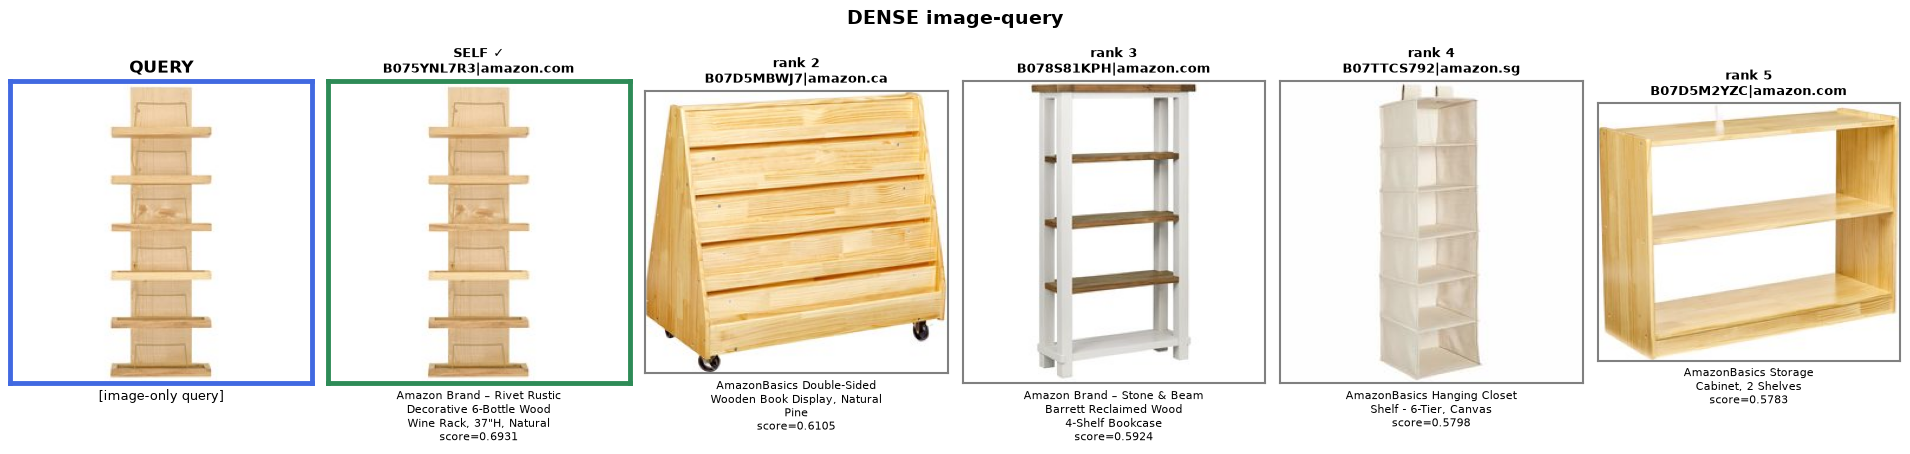

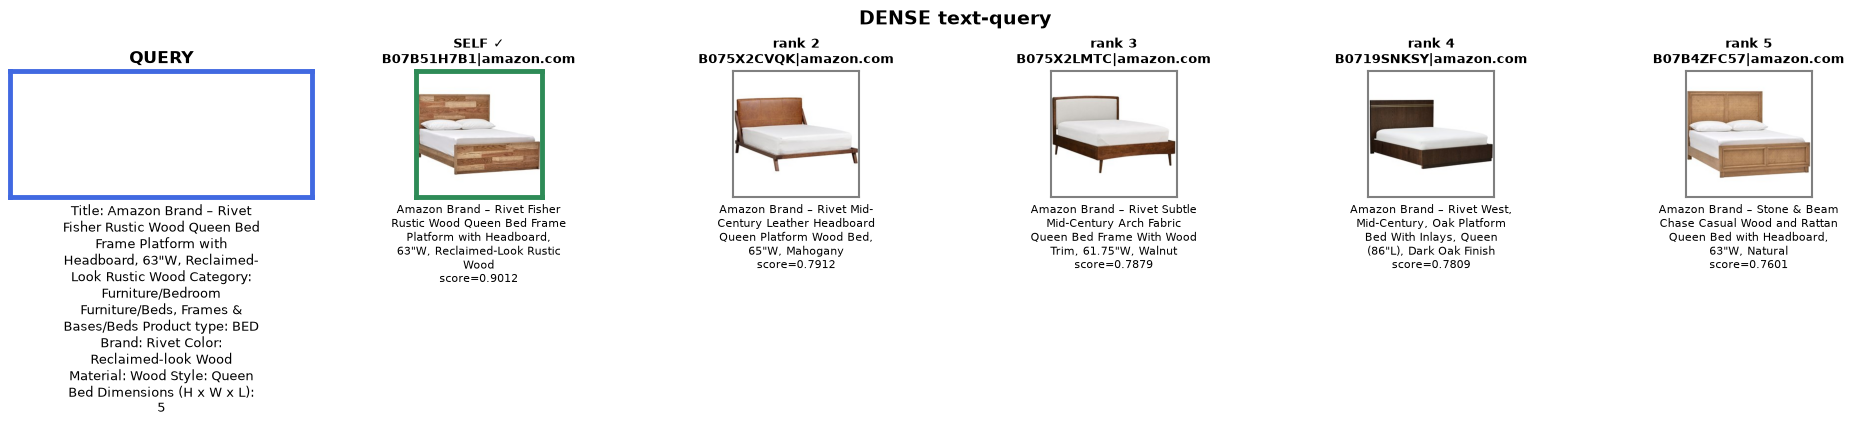

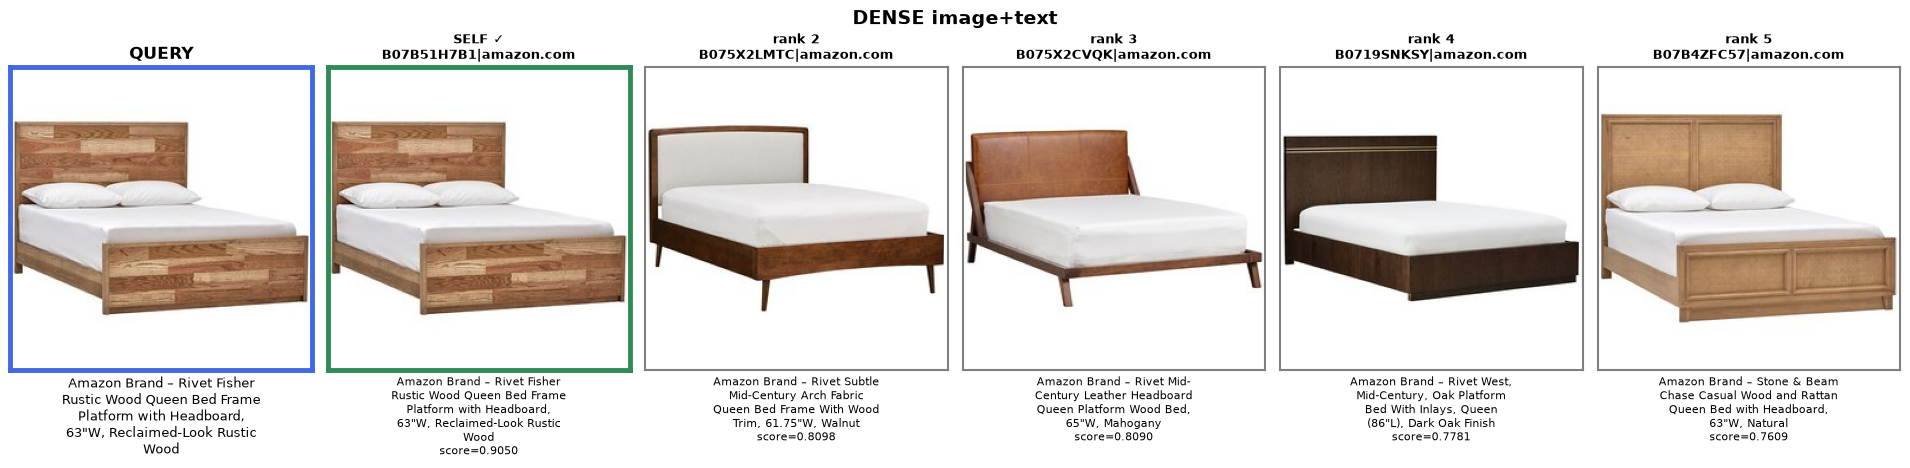

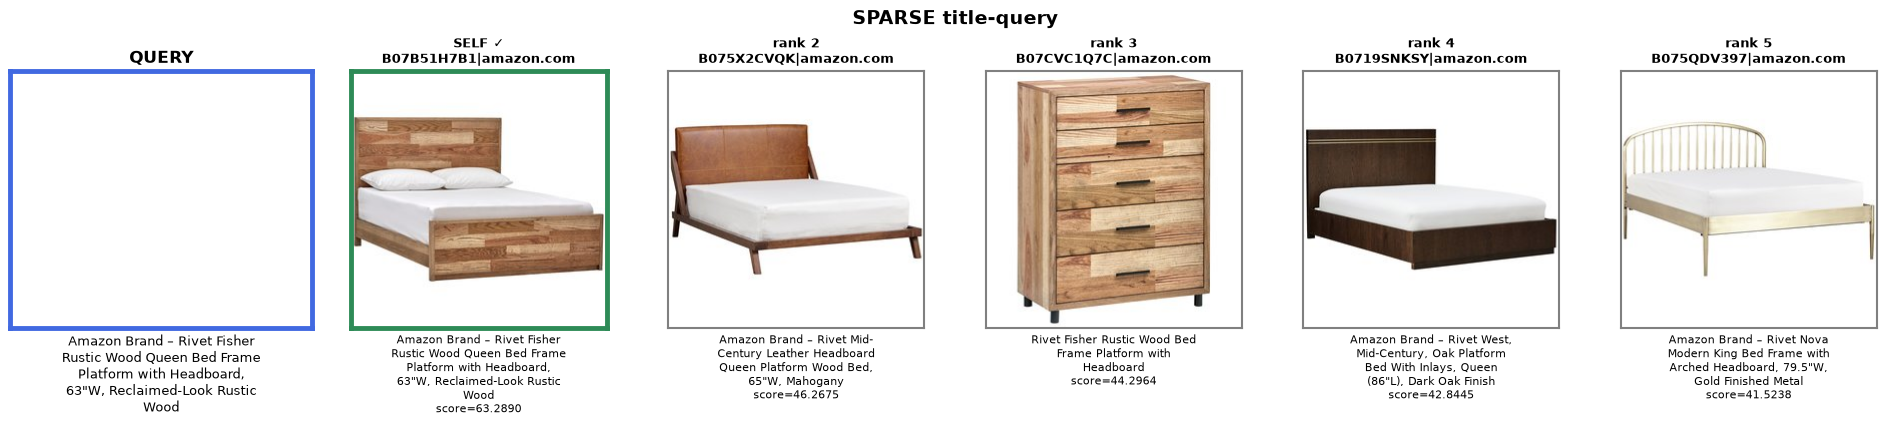

In [ ]:
# Representative self-retrieval probes selected by the sanity-check cell.
probe_specs = [
    ("DENSE image-query", "dense_image"),
    ("DENSE text-query", "dense_text"),
    ("DENSE image+text", "dense_multimodal"),
    ("SPARSE title-query", "sparse_title"),
]

for kind, _ in probe_specs:
    r = SANITY_PROBES[kind]
    if kind == "DENSE image-query":
        res = dense_search(encode_query_dense(image_paths[r]), SANITY_TOP_K)
        visualize(kind, res, query_image=image_paths[r], self_row=r)
    elif kind == "DENSE text-query":
        res = dense_search(encode_query_dense(product_texts[r]), SANITY_TOP_K)
        visualize(kind, res, query_text=product_texts[r][:300], self_row=r)
    elif kind == "DENSE image+text":
        qtext = str(catalog.iloc[r]["title"])
        res = dense_search(encode_query_dense({"text": qtext, "image": image_paths[r]}), SANITY_TOP_K)
        visualize(kind, res, query_image=image_paths[r], query_text=qtext, self_row=r)
    else:
        qtext = str(catalog.iloc[r]["title"])
        idx, val = splade_encode_batch([qtext], SPARSE_TOP_N)[0]
        res = sparse_search(idx, val, SANITY_TOP_K)
        visualize(kind, res, query_text=qtext, self_row=r)


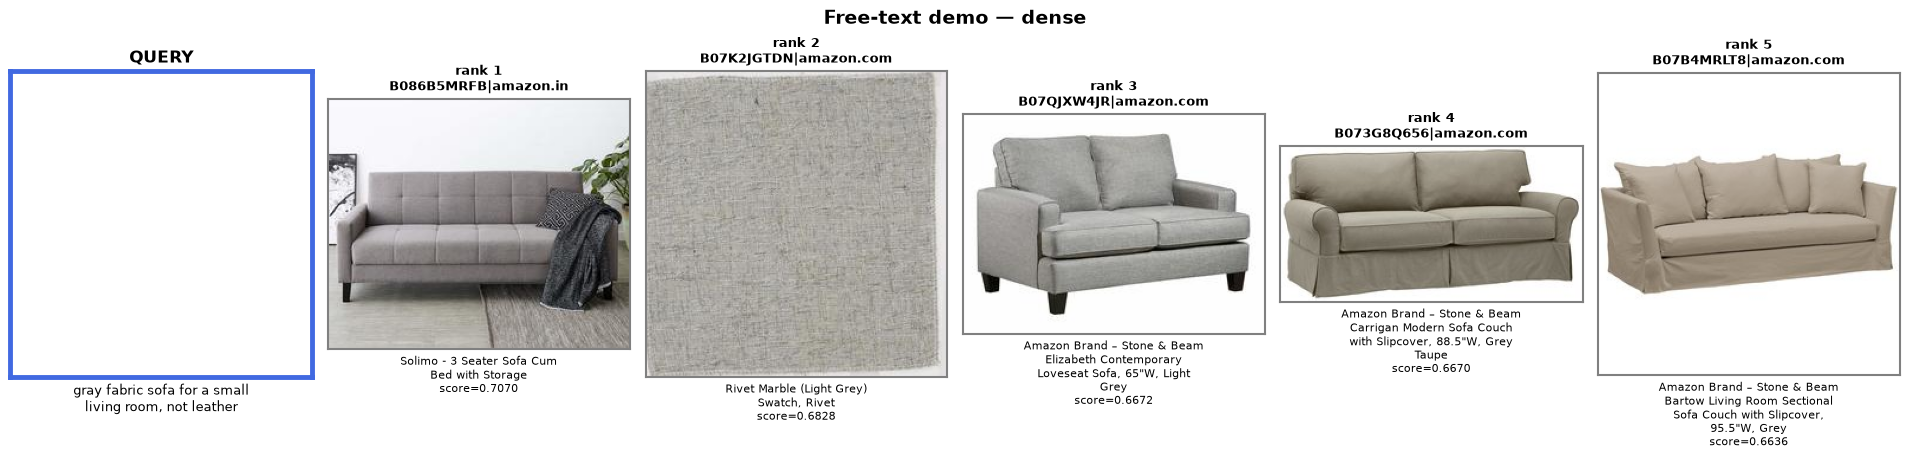

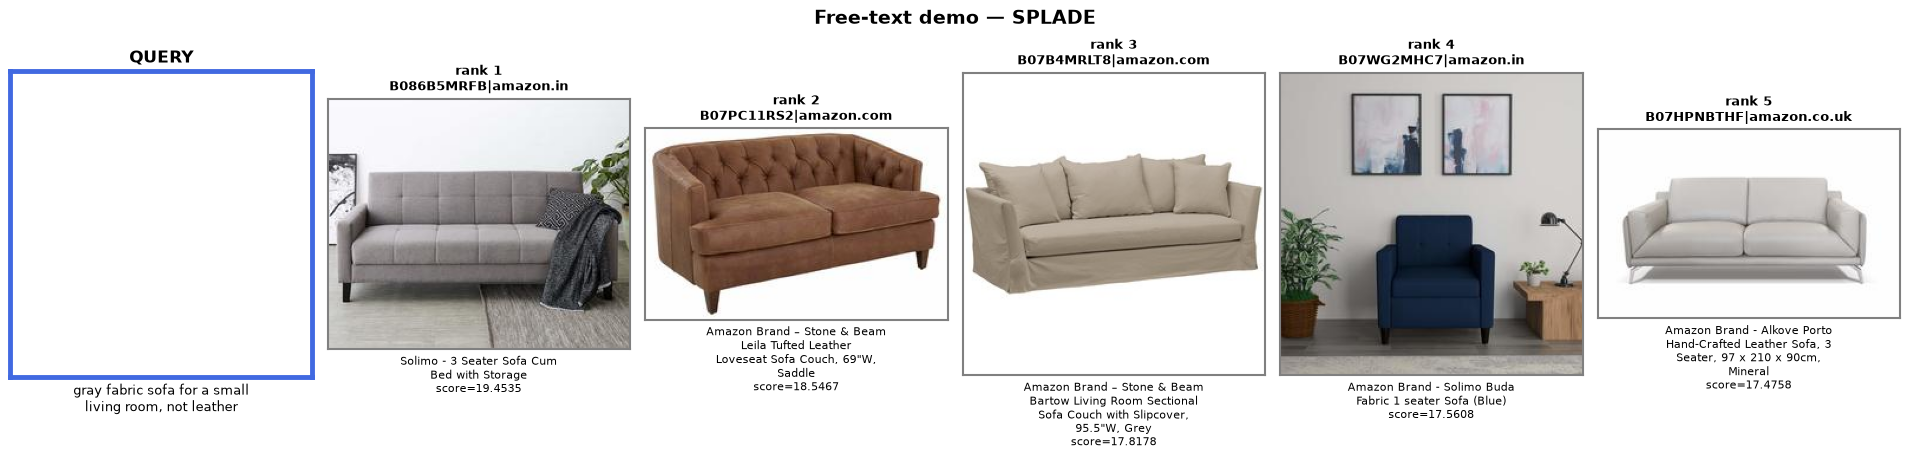

In [ ]:
# Free-text comparison: dense semantics versus SPLADE lexical evidence.
DEMO_QUERY = "gray fabric sofa for a small living room, not leather"

q_dense = encode_query_dense(DEMO_QUERY)
dense_demo = dense_search(q_dense, top_k=5)
q_idx, q_val = splade_encode_batch([DEMO_QUERY], SPARSE_TOP_N)[0]
sparse_demo = sparse_search(q_idx, q_val, top_k=5)

visualize("Free-text demo — dense", dense_demo, query_text=DEMO_QUERY, k=5)
visualize("Free-text demo — SPLADE", sparse_demo, query_text=DEMO_QUERY, k=5)


# Hybrid Retrieval and Cross-Encoder Reranking

Combine dense and sparse candidates with reciprocal rank fusion, then rerank text-bearing queries with `BAAI/bge-reranker-v2-m3`. Image-only queries preserve dense visual evidence.


In [ ]:
import os, sys, json, time, subprocess, zipfile, shutil
from pathlib import Path
PROJECT_ROOT = str(Path.cwd())
WORK = PROJECT_ROOT
print("Project:", PROJECT_ROOT)


In [ ]:
# Verify all Stage 0/1 artifacts before retrieval.
import os
need = [
    'data/catalog_subset.parquet',
    'data/queries.jsonl',
    'artifacts/embeddings/product_dense.npy',
    'artifacts/embeddings/product_ids.txt',
    'artifacts/embeddings/product_sparse.jsonl',
    'artifacts/index/dense_index.faiss',
    'artifacts/index/sparse_index.npz',
    'artifacts/index/index_manifest.json',
]
missing = [p for p in need if not os.path.exists(p)]
if missing:
    raise SystemExit("MISSING ARTIFACTS: " + ', '.join(missing))
print("all", len(need), "artifacts present")

import json
qs = [json.loads(l) for l in open('data/queries.jsonl', encoding='utf-8') if l.strip()]
print(f"queries: {len(qs)} "
      f"(text={sum(1 for q in qs if q['query_type']=='text')}, "
      f"image={sum(1 for q in qs if q['query_type']=='image')}, "
      f"image_text={sum(1 for q in qs if q['query_type']=='image_text')})")
assert len(qs) == 20, "Expected the fixed 20-query evaluation set."


In [ ]:
# --- 5. Imports + constants ---
import collections
import json
import os
import time

import numpy as np
import pandas as pd
import scipy.sparse as sp
import faiss
from tqdm.auto import tqdm

manifest = json.load(open("artifacts/index/index_manifest.json", encoding="utf-8"))
DENSE_MODEL  = manifest["dense_model"]
SPARSE_MODEL = manifest["sparse_model"]
SPARSE_VOCAB = int(manifest["sparse_vocab_size"])
SPARSE_TOP_N = int(manifest["sparse_top_n"])
DENSE_DIM    = int(manifest["dense_dimension"])
RRF_K        = 60
W_DENSE      = 0.55
W_SPARSE     = 0.45
TOP_K_DENSE  = 100
TOP_K_SPARSE = 100
PREFUSION    = "rrf"  # supported: "rrf" or "weighted"

OUT_DIR = "outputs"
EMB_DIR = "artifacts/embeddings"
INDEX_DIR = "artifacts/index"
DENSE_CACHE  = "artifacts/query_cache/dense_queries.npz"
SPARSE_CACHE = "artifacts/query_cache/sparse_queries.jsonl"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs("artifacts/query_cache", exist_ok=True)
os.makedirs("reports", exist_ok=True)

print("dense:", DENSE_MODEL, DENSE_DIM)
print("sparse:", SPARSE_MODEL, SPARSE_VOCAB, "top-N", SPARSE_TOP_N)
print("retrieval: dense top", TOP_K_DENSE, "sparse top", TOP_K_SPARSE, "prefusion", PREFUSION)


In [ ]:
# --- 6. Load catalog + indexes + queries ---
PROJECT_ROOT = os.path.abspath(os.getcwd())
print("[retrieve] loading catalog data/catalog_subset.parquet")
catalog = pd.read_parquet("data/catalog_subset.parquet")
catalog["abs_image_path"] = catalog["image_path"].map(
    lambda p: p if os.path.isabs(str(p)) else os.path.normpath(os.path.join(PROJECT_ROOT, str(p)))
)
print(f"catalog: {len(catalog)} rows")

print("[retrieve] loading FAISS index from artifacts/index")
dense_index = faiss.read_index(os.path.join(INDEX_DIR, "dense_index.faiss"))
print("[retrieve] loading CSR sparse index from artifacts/index")
sparse_index = sp.load_npz(os.path.join(INDEX_DIR, "sparse_index.npz"))
with open(os.path.join(EMB_DIR, "product_ids.txt"), encoding="utf-8") as f:
    product_ids = [l.strip() for l in f if l.strip()]
print(f"dense: {dense_index.ntotal} vectors, d={dense_index.d}; "
      f"sparse: {sparse_index.shape}, nnz={sparse_index.nnz}; ids: {len(product_ids)}")
assert dense_index.ntotal == len(product_ids) == sparse_index.shape[0] == len(catalog)
assert dense_index.d == DENSE_DIM and sparse_index.shape[1] == SPARSE_VOCAB

print("[retrieve] loading queries data/queries.jsonl")
queries = []
with open("data/queries.jsonl", encoding="utf-8") as f:
    for ln, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        q = json.loads(line)
        for k in ("query_id", "query_text", "query_image_path", "query_type", "split"):
            if k not in q:
                raise ValueError(f"line {ln} missing '{k}'")
        if q["query_type"] not in ("text", "image", "image_text"):
            raise ValueError(f"line {ln}: bad query_type {q['query_type']!r}")
        if q["query_type"] in ("text", "image_text") and not q["query_text"]:
            raise ValueError(f"line {ln}: text/image_text query needs query_text")
        if q["query_type"] in ("image", "image_text") and not q["query_image_path"]:
            raise ValueError(f"line {ln}: image/image_text query needs query_image_path")
        if q["query_image_path"]:
            rel = q["query_image_path"]
            q["abs_image_path"] = rel if os.path.isabs(rel) else os.path.normpath(os.path.join(PROJECT_ROOT, rel))
        queries.append(q)
print(f"queries: {len(queries)}; by type {dict(collections.Counter(q['query_type'] for q in queries))}")


In [ ]:
# --- 7. Load the same dense encoder used for product indexing ---
import torch
from sentence_transformers import SentenceTransformer

DENSE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"loading dense model {DENSE_MODEL} on {DENSE_DEVICE}")
try:
    dense_model = SentenceTransformer(
        DENSE_MODEL,
        device=DENSE_DEVICE,
        model_kwargs={"torch_dtype": torch.float16} if DENSE_DEVICE == "cuda" else None,
    )
except Exception as exc:
    print("preferred dtype load failed; retrying default:", exc)
    dense_model = SentenceTransformer(DENSE_MODEL, device=DENSE_DEVICE)

print("loaded:", DENSE_MODEL)


In [ ]:
# --- 8. Load SPLADE++ sparse encoder ---
from transformers import AutoTokenizer, AutoModelForMaskedLM

SPARSE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"loading sparse model {SPARSE_MODEL} on {SPARSE_DEVICE}")
sp_tokenizer = AutoTokenizer.from_pretrained(SPARSE_MODEL)
sp_model = AutoModelForMaskedLM.from_pretrained(SPARSE_MODEL).to(SPARSE_DEVICE).eval()
print("loaded:", SPARSE_MODEL, "| vocab:", sp_model.config.vocab_size)
assert int(sp_model.config.vocab_size) == SPARSE_VOCAB


@torch.no_grad()
def splade_encode_batch(texts, top_n=SPARSE_TOP_N, max_len=256):
    enc = sp_tokenizer(
        texts, padding=True, truncation=True,
        max_length=max_len, return_tensors="pt"
    ).to(SPARSE_DEVICE)
    logits = sp_model(**enc).logits
    weights = torch.log1p(torch.relu(logits))
    weights = weights * enc["attention_mask"].unsqueeze(-1)
    pooled = torch.max(weights, dim=1).values
    out = []
    for row in pooled:
        nz = torch.nonzero(row > 0, as_tuple=False).squeeze(-1)
        if nz.numel() == 0:
            out.append((np.empty(0, np.int32), np.empty(0, np.float32)))
            continue
        vals = row[nz]
        k = min(int(top_n), int(vals.numel()))
        top_vals, order = torch.topk(vals, k=k, largest=True, sorted=True)
        top_idx = nz[order]
        out.append((
            top_idx.detach().cpu().numpy().astype(np.int32),
            top_vals.detach().cpu().numpy().astype(np.float32),
        ))
    return out

print("splade_encode_batch ready")


In [ ]:
# --- 8b. Verify image-bearing queries. The fixed query set must be complete. ---
missing_query_images = []
for q in queries:
    if q.get('query_image_path') and not os.path.exists(q['abs_image_path']):
        missing_query_images.append((q['query_id'], q['abs_image_path']))
if missing_query_images:
    for qid, path in missing_query_images:
        print("MISSING", qid, path)
    raise FileNotFoundError("Fixed image/image+text query files are missing. Re-run Stage 0 image extraction.")
print(f"all image-bearing query files resolved; processing all {len(queries)} queries")


In [ ]:
# --- 9. Encode dense query vectors (cached) ---
from PIL import Image

cached_dense = {}
if os.path.isfile(DENSE_CACHE):
    with np.load(DENSE_CACHE, allow_pickle=False) as z:
        for k in z.files:
            cached_dense[k] = z[k].astype(np.float32)
    print(f"dense query cache hit: {len(cached_dense)} vectors")


def _load_image(path):
    return Image.open(path).convert("RGB")


def _dense_input_for_query(q):
    if q["query_type"] == "text":
        return q["query_text"]
    if q["query_type"] == "image":
        return _load_image(q["abs_image_path"])
    # Critical policy: image+text is encoded as one combined multimodal object.
    return {"text": q["query_text"], "image": _load_image(q["abs_image_path"])}


def _dense_encode_one(q):
    fn = getattr(dense_model, "encode_query", None) or dense_model.encode
    inp = _dense_input_for_query(q)
    arr = np.asarray(fn(
        inp,
        convert_to_numpy=True,
        normalize_embeddings=True,
        show_progress_bar=False,
    ), dtype=np.float32)
    if arr.ndim > 1:
        arr = arr[0]
    norm = float(np.linalg.norm(arr))
    if norm > 0:
        arr = arr / norm
    return arr.astype(np.float32)


todo = [q for q in queries if q["query_id"] not in cached_dense]
print(f"encoding {len(todo)} dense query vectors ({len(cached_dense)} cached)")
out = {}
for q in tqdm(todo, desc="dense query encode"):
    out[q["query_id"]] = _dense_encode_one(q)
all_dense = {**cached_dense, **out}
if out:
    os.makedirs(os.path.dirname(DENSE_CACHE), exist_ok=True)
    np.savez(DENSE_CACHE, **all_dense)
    print(f"saved {len(all_dense)} dense query vectors to {DENSE_CACHE}")
print("dense query vectors:", len(all_dense))


In [ ]:
import gc
import torch

# Dense query vectors have already been saved to disk.
del dense_model

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("Dense model unloaded.")

print(
    "GPU allocated:",
    round(torch.cuda.memory_allocated() / 1024**3, 2),
    "GB"
    if torch.cuda.is_available()
    else ""
)

In [ ]:
# --- 10. Encode sparse query vectors (cached) ---
sparse_cached = {}
if os.path.isfile(SPARSE_CACHE):
    with open(SPARSE_CACHE, encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            if rec.get("indices"):
                sparse_cached[rec["query_id"]] = (
                    np.asarray(rec["indices"], dtype=np.int32),
                    np.asarray(rec["values"], dtype=np.float32),
                )
    print(f"sparse query cache hit: {len(sparse_cached)} vectors")

todo = [q for q in queries
        if q["query_type"] in ("text", "image_text")
        and q["query_id"] not in sparse_cached]
print(f"encoding {len(todo)} sparse query vectors")
BATCH = 16
new_records = []
for s in tqdm(range(0, len(todo), BATCH), desc="sparse query encode"):
    q_batch = todo[s:s+BATCH]
    texts = [q["query_text"] for q in q_batch]
    encoded = splade_encode_batch(texts, top_n=SPARSE_TOP_N, max_len=256)
    for q, (idx, val) in zip(q_batch, encoded):
        sparse_cached[q["query_id"]] = (idx, val)
        new_records.append({
            "query_id": q["query_id"],
            "indices": [int(x) for x in idx.tolist()],
            "values": [float(x) for x in val.tolist()],
        })

if new_records:
    os.makedirs(os.path.dirname(SPARSE_CACHE), exist_ok=True)
    with open(SPARSE_CACHE, "a", encoding="utf-8") as f:
        for rec in new_records:
            f.write(json.dumps(rec) + "\n")
    print(f"appended {len(new_records)} sparse query vectors to {SPARSE_CACHE}")
print("sparse query vectors:", len(sparse_cached))


In [ ]:
import gc
import torch

del sp_model
del sp_tokenizer

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("SPLADE model unloaded.")

In [ ]:
# --- 11. Hybrid search + RRF/weighted prefusion + write outputs ---
def normalize_scores(pairs):
    if not pairs:
        return {}
    vals = np.array([s for _, s in pairs], dtype=np.float32)
    lo, hi = float(vals.min()), float(vals.max())
    if hi - lo < 1e-9:
        return {i: 0.0 for i, _ in pairs}
    return {i: float((s - lo) / (hi - lo)) for i, s in pairs}


def dense_search(di, q_vec, top_k):
    q = np.asarray(q_vec, dtype=np.float32).reshape(1, -1)
    norm = np.linalg.norm(q, axis=1, keepdims=True)
    norm[norm == 0] = 1.0
    q = q / norm
    scores, idx = di.search(np.ascontiguousarray(q), min(top_k, di.ntotal))
    return [(int(i), float(s)) for i, s in zip(idx[0], scores[0]) if i != -1]


def sparse_search(si, q_idx, q_val, top_k):
    if q_idx is None or len(q_idx) == 0:
        return []
    v = np.zeros(si.shape[1], dtype=np.float32)
    v[np.asarray(q_idx, dtype=np.int64)] = np.asarray(q_val, dtype=np.float32)
    scores = np.asarray(si.dot(v)).ravel()
    k = min(int(top_k), len(scores))
    if k == len(scores):
        top = np.argsort(-scores)
    else:
        top = np.argpartition(-scores, k - 1)[:k]
        top = top[np.argsort(-scores[top])]
    return [(int(i), float(scores[i])) for i in top]


def merge_and_score(d_hits, s_hits, query_type, prefusion_method):
    sparse_applicable = query_type in ("text", "image_text")
    d_norm = normalize_scores(d_hits)
    s_norm = normalize_scores(s_hits) if sparse_applicable else {}
    d_rank = {i: r for r, (i, _) in enumerate(d_hits, start=1)}
    s_rank = {i: r for r, (i, _) in enumerate(s_hits, start=1)}
    d_score_map = {i: s for i, s in d_hits}
    s_score_map = {i: s for i, s in s_hits}
    candidates = set(d_score_map) | set(s_score_map)

    rows = []
    for i in candidates:
        src = []
        if i in d_score_map:
            src.append("dense")
        if i in s_score_map:
            src.append("sparse")
        d_raw = d_score_map.get(i)
        s_raw = s_score_map.get(i) if sparse_applicable else None

        if not sparse_applicable:
            pf = float(d_norm.get(i, 0.0))
        elif prefusion_method.lower() == "rrf":
            pf = 0.0
            if i in d_rank:
                pf += 1.0 / (RRF_K + d_rank[i])
            if i in s_rank:
                pf += 1.0 / (RRF_K + s_rank[i])
        elif prefusion_method.lower() == "weighted":
            pf = W_DENSE * d_norm.get(i, 0.0) + W_SPARSE * s_norm.get(i, 0.0)
        else:
            raise ValueError(f"Unsupported prefusion method: {prefusion_method}")
        rows.append((i, d_raw, s_raw, float(pf), src))

    rows.sort(key=lambda x: (-x[3], -(x[1] if x[1] is not None else -1e30), x[0]))
    return rows


out_records = []
n_unique_cands, dense_n, sparse_n, overlap = [], 0, 0, 0
t0 = time.time()
for q in tqdm(queries, desc="retrieval"):
    qid = q["query_id"]
    d_hits = dense_search(dense_index, all_dense[qid], TOP_K_DENSE)
    s_hits = []
    if q["query_type"] in ("text", "image_text"):
        qidx, qval = sparse_cached[qid]
        s_hits = sparse_search(sparse_index, qidx, qval, TOP_K_SPARSE)
    merged = merge_and_score(d_hits, s_hits, q["query_type"], PREFUSION)
    sparse_applicable = q["query_type"] in ("text", "image_text")
    results = []
    d_set = {i for i, _ in d_hits}
    s_set = {i for i, _ in s_hits}
    for rank, (i, d_s, s_s, pf_s, src) in enumerate(merged, 1):
        results.append({
            "rank": rank,
            "product_id": product_ids[i],
            "dense_score": d_s,
            "sparse_score": s_s if sparse_applicable else None,
            "prefusion_score": pf_s,
            "source": src,
        })
    out_records.append({
        "query_id": qid,
        "query_type": q["query_type"],
        "run_name": "hybrid_dense_sparse_prefusion",
        "sparse_applicable": sparse_applicable,
        "results": results,
    })
    dense_n += len(d_hits)
    sparse_n += len(s_hits)
    overlap += len(d_set & s_set)
    n_unique_cands.append(len(merged))

print(f"\nretrieval done in {time.time()-t0:.1f}s | "
      f"mean unique cands/query={np.mean(n_unique_cands):.1f} | "
      f"mean dense-hits={dense_n/len(queries):.1f} | "
      f"mean sparse-hits={sparse_n/len(queries):.1f} | "
      f"mean overlap={overlap/len(queries):.1f}")

with open(f"{OUT_DIR}/retrieval_results.jsonl", "w", encoding="utf-8") as f:
    for r in out_records:
        f.write(json.dumps(r) + "\n")
print(f"wrote {len(out_records)} lines to outputs/retrieval_results.jsonl")

by_type = collections.Counter(q["query_type"] for q in queries)
examples = []
for r in out_records[:3]:
    top3 = r["results"][:3]
    examples.append(f"- **{r['query_id']}** ({r['query_type']}) -> " + ", ".join(
        f"#{x['rank']} {x['product_id']} (pf={x['prefusion_score']:.4f})" for x in top3))
md = [
    "# Stage 2 - Retrieval Summary", "",
    f"- Queries by type: text={by_type.get('text',0)}, image={by_type.get('image',0)}, image_text={by_type.get('image_text',0)} (total={len(queries)})",
    f"- Dense top-K: {TOP_K_DENSE} | Sparse top-K: {TOP_K_SPARSE}",
    f"- Prefusion method: **{PREFUSION}** (RRF k={RRF_K} | weighted w_dense={W_DENSE}, w_sparse={W_SPARSE})",
    f"- Average unique candidates per query: **{np.mean(n_unique_cands):.1f}**",
    f"- Average candidates in BOTH dense and sparse: **{overlap/len(queries):.1f}**",
    "- Image-only queries use dense retrieval only (`sparse_applicable=false`).", "",
    "## Top results for the first 3 queries", "", *examples, "",
]
with open("reports/retrieval_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(md))
print("wrote reports/retrieval_summary.md")


In [ ]:
# --- 12. Stage 2 schema sanity tests (inline) ---
import json, os
n_pass = n_fail = 0

def check(name, cond):
    global n_pass, n_fail
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")
    if cond: n_pass += 1
    else: n_fail += 1

records = [json.loads(l) for l in open("outputs/retrieval_results.jsonl", encoding="utf-8") if l.strip()]
check("retrieval_results.jsonl has all 20 queries", len(records) == 20)
catalog = pd.read_parquet("data/catalog_subset.parquet")
catalog_ids = set(catalog["product_id"].astype(str).tolist())
queries_by_id = {q["query_id"]: q for q in queries}
for r in records:
    check(f"{r['query_id']} in queries", r["query_id"] in queries_by_id)
    check(f"{r['query_id']} run_name is hybrid", r.get("run_name") == "hybrid_dense_sparse_prefusion")
    check(f"{r['query_id']} sparse_applicable matches",
          r.get("sparse_applicable") == (queries_by_id[r["query_id"]]["query_type"] != "image"))
    hits = r.get("results", [])
    check(f"{r['query_id']} ranks consecutive", [h['rank'] for h in hits] == list(range(1, len(hits)+1)))
    check(f"{r['query_id']} no duplicate IDs", len({h['product_id'] for h in hits}) == len(hits))
    for h in hits:
        check(f"{r['query_id']} hit {h['product_id']} in catalog", h["product_id"] in catalog_ids)
        check(f"{r['query_id']} hit has prefusion_score", "prefusion_score" in h)
        check(f"{r['query_id']} hit has source", "source" in h)
print(f"\n{n_pass} passed, {n_fail} failed")

!python src/tests.py --stage 2 \
  --catalog data/catalog_subset.parquet \
  --queries data/queries.jsonl \
  --retrieval outputs/retrieval_results.jsonl


In [ ]:
# --- 13. Load BGE cross-encoder reranker ---
from sentence_transformers import CrossEncoder

CE_MODEL_NAME = "BAAI/bge-reranker-v2-m3"
CE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CE_MAX_LENGTH = 512
print(f"loading cross-encoder {CE_MODEL_NAME} on {CE_DEVICE}")
ce_model = CrossEncoder(CE_MODEL_NAME, device=CE_DEVICE, max_length=CE_MAX_LENGTH)
print("loaded:", CE_MODEL_NAME)


In [ ]:
# --- 14. Build the (query_text, product_text) rerank input pairs ---
# Uses product metadata fields: title, product_type, category, brand, color,
# material, style, bullet points, description.
import math

cat_by_id = {str(r.product_id): r for r in catalog.itertuples()}


def _safe(v, default=''):
    if v is None:
        return default
    if isinstance(v, float) and math.isnan(v):
        return default
    return str(v)


def build_product_text(row, max_chars=6000):
    fields = {
        "Title": _safe(getattr(row, 'title', None)),
        "Category": _safe(getattr(row, 'category_path', None)),
        "Product type": _safe(getattr(row, 'product_type', None)),
        "Brand": _safe(getattr(row, 'brand', None)),
        "Color": _safe(getattr(row, 'color', None)),
        "Material": _safe(getattr(row, 'material', None)),
        "Style": _safe(getattr(row, 'style', None)),
        "Features": _safe(getattr(row, 'bullet_points', None)),
        "Description": _safe(getattr(row, 'description', None)),
    }
    text = "\n".join(f"{name}: {value}" for name, value in fields.items() if value.strip())
    return text[:max_chars]


def query_text_for(q):
    # A text cross-encoder has no valid textual signal for image-only queries.
    # Those queries are intentionally handled as dense-only in the fused ranking.
    return "" if q["query_type"] == "image" else str(q["query_text"])

RERANK_TOP_N = 100
print(f"building rerank input pairs (top {RERANK_TOP_N} per query)")
pairs_per_query = []
for r in tqdm(out_records, desc="build pairs"):
    q = queries_by_id[r["query_id"]]
    hits = r["results"][:RERANK_TOP_N]
    if q["query_type"] == "image":
        pairs = []
    else:
        qtext = query_text_for(q)
        pairs = [
            (qtext, build_product_text(cat_by_id[h["product_id"]]))
            for h in hits if h["product_id"] in cat_by_id
        ]
    pairs_per_query.append((r["query_id"], q["query_type"], pairs))
total = sum(len(p[2]) for p in pairs_per_query)
print(f"total text cross-encoder pairs to score: {total}")


In [ ]:
# --- 15. Score all pairs with BGE + write reranked outputs ---
import math


def zscore(vals):
    if not vals:
        return []
    arr = np.array(vals, dtype=np.float32)
    sd = float(arr.std())
    if sd < 1e-9:
        return [0.0] * len(vals)
    mu = float(arr.mean())
    return [float((v - mu) / sd) for v in arr]

# Fixed, explicit per-query-type fusion policy.
WEIGHTS = {
    "text": {"ce": 0.65, "dense": 0.20, "sparse": 0.15},
    "image": {"ce": 0.00, "dense": 1.00, "sparse": 0.00},
    "image_text": {"ce": 0.55, "dense": 0.30, "sparse": 0.15},
}

rerank_records = []
strategy_a_lines = []
t0 = time.time()
retrieval_by_id = {r["query_id"]: r for r in out_records}

for qid, qtype, pairs in tqdm(pairs_per_query, desc="rerank"):
    hits = retrieval_by_id[qid]["results"][:RERANK_TOP_N]
    weights = WEIGHTS[qtype]
    if qtype == "image":
        ce_scores = [0.0] * len(hits)
    else:
        pred = ce_model.predict(pairs, batch_size=16, show_progress_bar=False)
        ce_scores = [float(x) for x in np.asarray(pred).reshape(-1)]
        if len(ce_scores) != len(hits):
            raise ValueError(f"{qid}: reranker returned {len(ce_scores)} scores for {len(hits)} hits")

    dense_raw = [float(h["dense_score"] or 0.0) for h in hits]
    sparse_raw = [float(h["sparse_score"] or 0.0) if h.get("sparse_score") is not None else 0.0 for h in hits]
    ce_z = zscore(ce_scores) if qtype != "image" else [0.0] * len(hits)
    dense_z = zscore(dense_raw)
    sparse_z = zscore(sparse_raw) if qtype != "image" else [0.0] * len(hits)

    scored = []
    for i, h in enumerate(hits):
        final = (
            weights["ce"] * ce_z[i]
            + weights["dense"] * dense_z[i]
            + weights["sparse"] * sparse_z[i]
        )
        row = dict(h)
        row["cross_encoder_score"] = float(ce_scores[i])
        row["final_score"] = float(final)
        scored.append(row)

    # Strategy A: cross-encoder alone for text-bearing queries.
    if qtype == "image":
        strategy_a_results = []
    else:
        ce_sorted = sorted(scored, key=lambda h: (-h["cross_encoder_score"], h["product_id"]))
        strategy_a_results = []
        for rank, h in enumerate(ce_sorted, 1):
            x = dict(h)
            x["rank"] = rank
            x["final_score"] = float(h["cross_encoder_score"])
            strategy_a_results.append(x)
    strategy_a_lines.append({
        "query_id": qid,
        "query_type": qtype,
        "run_name": "hybrid_cross_encoder",
        "reranker_type": "text_cross_encoder",
        "results": strategy_a_results,
    })

    fused_sorted = sorted(
        scored,
        key=lambda h: (-h["final_score"], -h["prefusion_score"], h["product_id"]),
    )
    fused_results = []
    for rank, h in enumerate(fused_sorted, 1):
        x = dict(h)
        x["rank"] = rank
        fused_results.append(x)
    rerank_records.append({
        "query_id": qid,
        "query_type": qtype,
        "run_name": "hybrid_cross_encoder_fused",
        "reranker_type": "text_cross_encoder_with_multimodal_dense_fusion",
        "results": fused_results,
    })

print(f"\nrerank done in {time.time()-t0:.1f}s")

with open(f"{OUT_DIR}/reranked_results.jsonl", "w", encoding="utf-8") as f:
    for r in rerank_records:
        f.write(json.dumps(r) + "\n")
print(f"wrote {len(rerank_records)} lines to outputs/reranked_results.jsonl")

with open(f"{OUT_DIR}/reranked_strategy_a.jsonl", "w", encoding="utf-8") as f:
    for r in strategy_a_lines:
        f.write(json.dumps(r) + "\n")
print(f"wrote strategy A ordering to outputs/reranked_strategy_a.jsonl")

for qt in ("text", "image", "image_text"):
    rows = [r for r in rerank_records if r["query_type"] == qt]
    print(f"\n=== {qt}: {len(rows)} queries ===")
    for r in rows[:3]:
        top1 = r["results"][0]
        q = queries_by_id[r["query_id"]]
        print(f"  {r['query_id']} -> {top1['product_id']} "
              f"(final={top1['final_score']:.3f}, q='{(q.get('query_text') or q.get('query_image_path',''))[:60]}')")


In [ ]:
# --- 16. Write reranking_summary.md ---
def find_by(qt, need_neg=False):
    for r in rerank_records:
        q = queries_by_id[r["query_id"]]
        if q["query_type"] != qt:
            continue
        if need_neg and " not " not in (q.get("query_text") or "").lower():
            continue
        return r, q
    return None, None

examples = []
for qt, need_neg in [("text", False), ("text", True), ("image", False), ("image_text", False)]:
    rr, q = find_by(qt, need_neg)
    if rr is None:
        continue
    before = retrieval_by_id[rr["query_id"]]["results"][0]["product_id"]
    after = rr["results"][0]["product_id"]
    examples.append(
        f"- {rr['query_id']} ({qt}): top-1 before `{before}` -> after `{after}`; "
        f"query=`{(q.get('query_text') or q.get('query_image_path'))}`"
    )

counts = collections.Counter(r["query_type"] for r in rerank_records)
lines = [
    "# Stage 3 - Reranking Summary", "",
    f"- Reranker: `{CE_MODEL_NAME}`",
    "- Pair format: `(query_text, structured product metadata text)` for text-bearing queries.",
    f"- Reranking depth: top {RERANK_TOP_N} Stage 2 candidates per query.",
    "- Score normalization: per-query z-score for cross-encoder, dense, and sparse signals.",
    f"- Fusion weights: `{json.dumps(WEIGHTS)}`",
    f"- Queries reranked: text={counts['text']}, image={counts['image']}, image_text={counts['image_text']}.",
    "- Image-only policy: text cross-encoder contribution is 0; final ranking preserves dense visual evidence.",
    "- Image+text policy: the cross-encoder uses query text while the dense score preserves the combined visual+text query signal.",
    "", "## Before/after examples", "", *examples, "",
]
with open("reports/reranking_summary.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))
print("wrote reports/reranking_summary.md")
print("\n".join(lines))


In [ ]:
# --- 17. Stage 3 schema sanity tests (inline) ---
import json, os
n_pass = n_fail = 0

def check(name, cond):
    global n_pass, n_fail
    print(f"  [{'PASS' if cond else 'FAIL'}] {name}")
    if cond: n_pass += 1
    else: n_fail += 1

rr = [json.loads(l) for l in open("outputs/reranked_results.jsonl", encoding="utf-8") if l.strip()]
ret = {r["query_id"]: r for r in out_records}
catalog_ids = set(catalog["product_id"].astype(str).tolist())
check("reranked output has all 20 queries", len(rr) == 20)
for r in rr:
    check(f"{r['query_id']} exists in retrieval", r["query_id"] in ret)
    if r["query_id"] in ret:
        ret_ids = {h["product_id"] for h in ret[r["query_id"]]["results"]}
        rer_ids = {h["product_id"] for h in r["results"]}
        check(f"{r['query_id']} rerank is subset of retrieval", rer_ids.issubset(ret_ids))
    hits = r.get("results", [])
    check(f"{r['query_id']} ranks consecutive", [h['rank'] for h in hits] == list(range(1, len(hits)+1)))
    check(f"{r['query_id']} no duplicate IDs", len({h['product_id'] for h in hits}) == len(hits))
    for h in hits:
        check(f"{r['query_id']} hit {h['product_id']} in catalog", h["product_id"] in catalog_ids)
        check(f"{r['query_id']} hit has final_score", "final_score" in h)
        check(f"{r['query_id']} hit has cross_encoder_score", "cross_encoder_score" in h)
        check(f"{r['query_id']} hit has source", "source" in h)
print(f"\n{n_pass} passed, {n_fail} failed")

!python src/tests.py --stage 3 \
  --catalog data/catalog_subset.parquet \
  --queries data/queries.jsonl \
  --retrieval outputs/retrieval_results.jsonl \
  --reranked outputs/reranked_results.jsonl


In [ ]:
# --- 18b. Print final Stage 2/3 results summary ---
import json

def load_jsonl(p):
    return [json.loads(l) for l in open(p, encoding='utf-8') if l.strip()]

ret = load_jsonl('outputs/retrieval_results.jsonl')
rer = load_jsonl('outputs/reranked_results.jsonl')
ret_map_summary = {r['query_id']: r for r in ret}
rer_map_summary = {r['query_id']: r for r in rer}

print('QUERY COUNTS:', dict(collections.Counter(r['query_type'] for r in ret)))
pool_sizes = [len(r['results']) for r in ret]
print('CANDIDATE POOL RANGE:', min(pool_sizes), '..', max(pool_sizes), 'mean', round(float(np.mean(pool_sizes)), 1))

source_counts = collections.Counter()
for r in ret:
    for h in r['results']:
        source_counts['+'.join(h.get('source', []))] += 1
print('SOURCE BREAKDOWN:', dict(source_counts))

changes = []
rank_shifts = []
for qid in ret_map_summary:
    before_hits = ret_map_summary[qid]['results']
    after_hits = rer_map_summary[qid]['results']
    if not before_hits or not after_hits:
        continue
    before_top = before_hits[0]['product_id']
    after_top = after_hits[0]['product_id']
    if before_top != after_top:
        changes.append((qid, before_top, after_top))
    before_rank = {h['product_id']: h['rank'] for h in before_hits}
    for h in after_hits[:10]:
        rank_shifts.append((before_rank.get(h['product_id'], 999) - h['rank'], qid, h['product_id']))
print(f'TOP-1 CHANGES: {len(changes)}/{len(ret_map_summary)}')
for row in changes[:8]:
    print(' ', row[0], row[1], '->', row[2])

print('\nLARGEST UPWARD RANK SHIFTS:')
for shift, qid, pid in sorted(rank_shifts, reverse=True)[:10]:
    print(f'  {qid}: {pid} moved up {shift} positions')

print('\nTOP PRODUCTS AFTER RERANK:')
for r in rer[:8]:
    q = queries_by_id[r['query_id']]
    h = r['results'][0]
    print(f"  {r['query_id']} ({r['query_type']}): {h['product_id']} final={h['final_score']:.3f} | {(q.get('query_text') or '[image]')[:70]}")

print('\nNEGATION CASES:')
for r in rer:
    q = queries_by_id[r['query_id']]
    if ' not ' in (q.get('query_text') or '').lower():
        before = ret_map_summary[r['query_id']]['results'][0]['product_id']
        after = r['results'][0]['product_id']
        print(f"  {r['query_id']}: {before} -> {after} | {q['query_text']}")


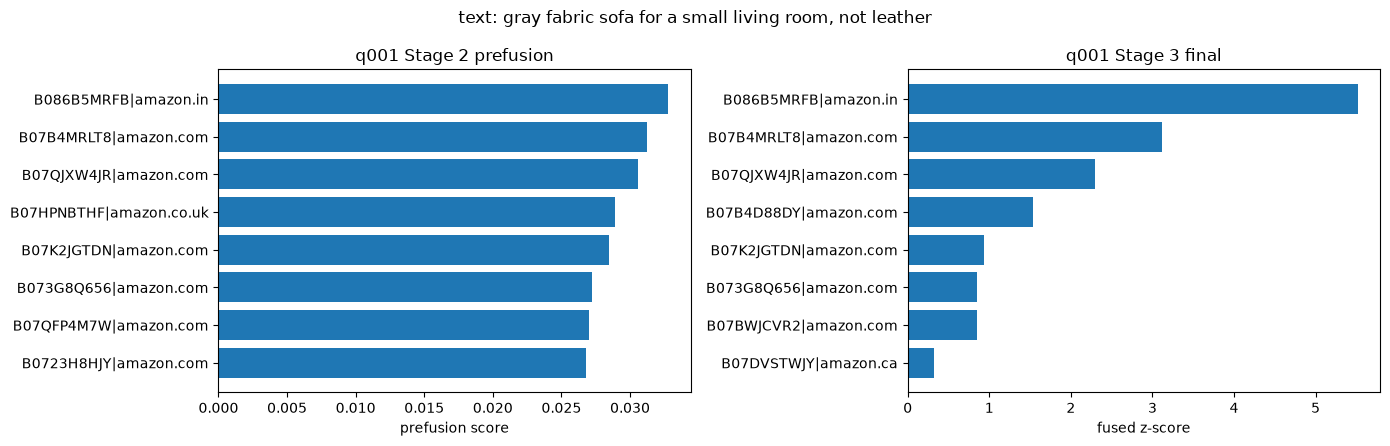

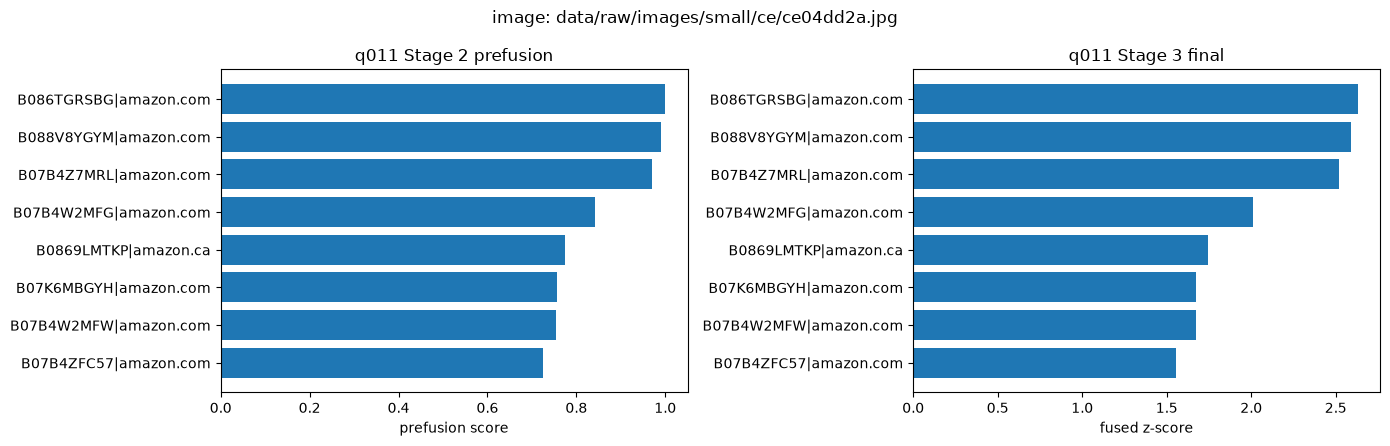

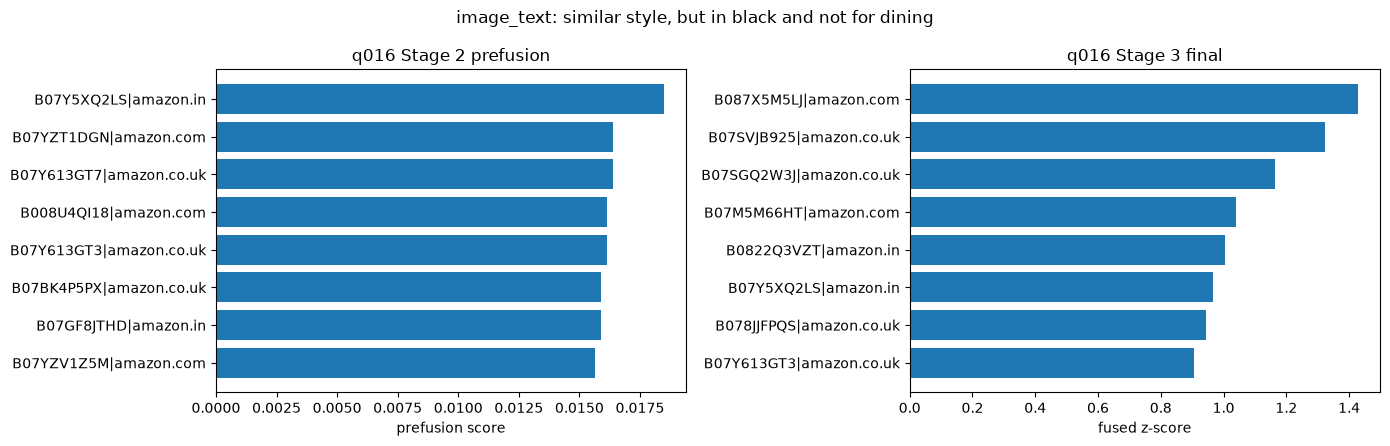

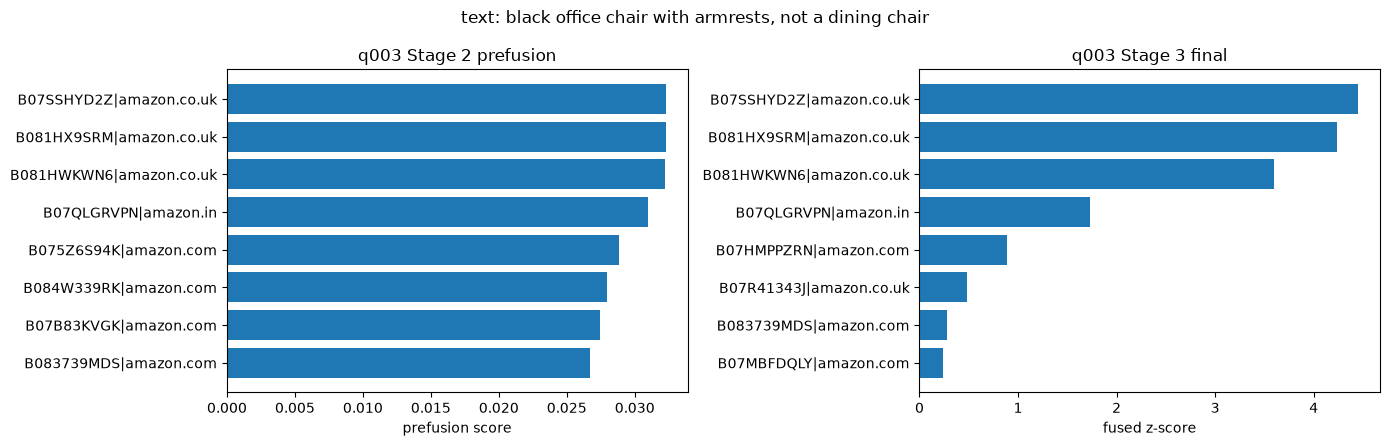

,query_id,type,before_top1,after_top1,changed
0,q001,text,B086B5MRFB|amazon.in,B086B5MRFB|amazon.in,False
1,q002,text,B07J1YW3YT|amazon.com,B07DBF3VJY|amazon.com,True
2,q003,text,B07SSHYD2Z|amazon.co.uk,B07SSHYD2Z|amazon.co.uk,False
3,q004,text,B075ZF4S39|amazon.com,B07PPNNCM2|amazon.com,True
4,q005,text,B07DBCMTPB|amazon.com,B07DBCMTPB|amazon.com,False
5,q006,text,B00DBSSHTY|amazon.co.uk,B00R3Z4J7U|amazon.ca,True
6,q007,text,B071LQHVJZ|amazon.com,B071LQHVJZ|amazon.com,False
7,q008,text,B07B8FHTJ4|amazon.com,B07B8FHTJ4|amazon.com,False
8,q009,text,B07P6XKV3B|amazon.in,B07P6XKV3B|amazon.in,False
9,q010,text,B078JMJC49|amazon.com,B078JMJC49|amazon.com,False


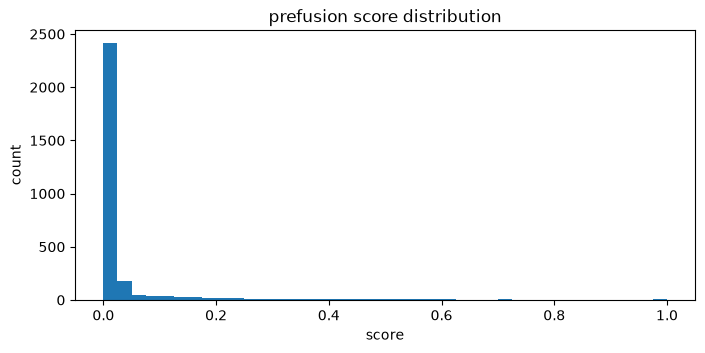

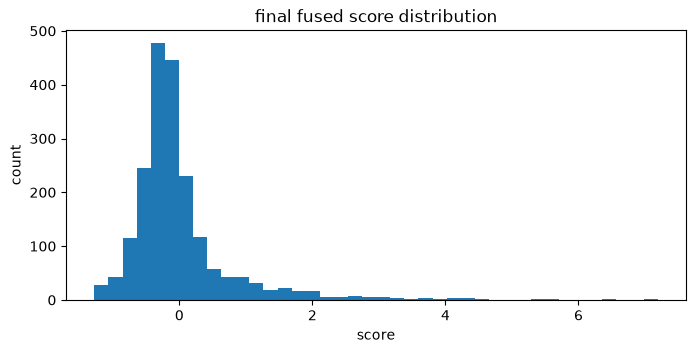

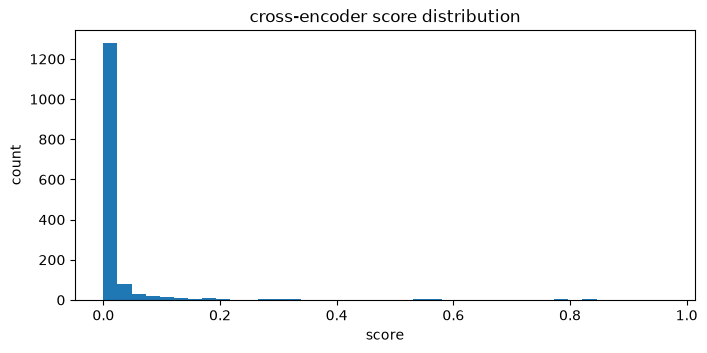

In [ ]:
# --- 19. Inline visualization: before vs after rerank ---
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ret_map = {r['query_id']: r for r in out_records}
rer_map = {r['query_id']: r for r in rerank_records}
queries_by_id_map = {q['query_id']: q for q in queries}

# Representative text, image, image+text, and explicit-negation queries.
representatives = []
for qt in ('text', 'image', 'image_text'):
    q = next(q for q in queries if q['query_type'] == qt)
    representatives.append(q['query_id'])
neg_q = next((q for q in queries if ' not ' in (q.get('query_text') or '').lower()
              and q['query_id'] not in representatives), None)
if neg_q:
    representatives.append(neg_q['query_id'])

for qid in representatives:
    q = queries_by_id_map[qid]
    before = ret_map[qid]['results'][:8]
    after = rer_map[qid]['results'][:8]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    axes[0].barh([h['product_id'] for h in before][::-1], [h['prefusion_score'] for h in before][::-1])
    axes[0].set_title(f'{qid} Stage 2 prefusion')
    axes[0].set_xlabel('prefusion score')
    axes[1].barh([h['product_id'] for h in after][::-1], [h['final_score'] for h in after][::-1])
    axes[1].set_title(f'{qid} Stage 3 final')
    axes[1].set_xlabel('fused z-score')
    fig.suptitle(f"{q['query_type']}: {(q.get('query_text') or q.get('query_image_path'))}")
    plt.tight_layout()
    plt.show()

# Compact top-1 change table.
rows = []
for q in queries:
    qid = q['query_id']
    b = ret_map[qid]['results'][0]
    a = rer_map[qid]['results'][0]
    rows.append({
        'query_id': qid,
        'type': q['query_type'],
        'before_top1': b['product_id'],
        'after_top1': a['product_id'],
        'changed': b['product_id'] != a['product_id'],
    })
display(pd.DataFrame(rows))

# Score distributions across all candidates.
prefusion_scores = [h['prefusion_score'] for r in ret for h in r['results']]
final_scores = [h['final_score'] for r in rer for h in r['results']]
ce_scores = [h['cross_encoder_score'] for r in rer if r['query_type'] != 'image' for h in r['results']]
for name, vals in [('prefusion', prefusion_scores), ('final fused', final_scores), ('cross-encoder', ce_scores)]:
    plt.figure(figsize=(8, 3.5))
    plt.hist(vals, bins=40)
    plt.title(f'{name} score distribution')
    plt.xlabel('score')
    plt.ylabel('count')
    plt.show()


In [ ]:
# --- 20. SELF-TEST: validate the whole Stage 2/3 pipeline output ---
import json, os
import pandas as pd
from IPython.display import display, Markdown

TEST_ROWS = []

def section(title):
    display(Markdown(f"## {title}"))


def check(name, cond, detail=''):
    row = {'check': name, 'status': 'PASS' if bool(cond) else 'FAIL', 'detail': str(detail)}
    TEST_ROWS.append(row)
    print(f"[{'PASS' if cond else 'FAIL'}] {name}" + (f" — {detail}" if detail else ''))
    return bool(cond)

ret_test = load_jsonl('outputs/retrieval_results.jsonl')
rer_test = load_jsonl('outputs/reranked_results.jsonl')
queries_test = load_jsonl('data/queries.jsonl')
catalog_test = pd.read_parquet('data/catalog_subset.parquet')
ret_by = {r['query_id']: r for r in ret_test}
rer_by = {r['query_id']: r for r in rer_test}
q_by = {q['query_id']: q for q in queries_test}
catalog_ids_test = set(catalog_test['product_id'].astype(str))

section('Coverage and schema')
check('20 retrieval records', len(ret_test) == 20, len(ret_test))
check('20 rerank records', len(rer_test) == 20, len(rer_test))
check('same query IDs across inputs/outputs', set(q_by) == set(ret_by) == set(rer_by))

for qid in sorted(q_by):
    rh = ret_by[qid]['results']
    fh = rer_by[qid]['results']
    check(f'{qid} retrieval ranks consecutive', [h['rank'] for h in rh] == list(range(1, len(rh)+1)))
    check(f'{qid} rerank ranks consecutive', [h['rank'] for h in fh] == list(range(1, len(fh)+1)))
    check(f'{qid} no retrieval duplicates', len({h['product_id'] for h in rh}) == len(rh))
    check(f'{qid} no rerank duplicates', len({h['product_id'] for h in fh}) == len(fh))
    check(f'{qid} rerank subset of retrieval', {h['product_id'] for h in fh}.issubset({h['product_id'] for h in rh}))
    check(f'{qid} all IDs in catalog', all(h['product_id'] in catalog_ids_test for h in rh + fh))
    if q_by[qid]['query_type'] == 'image':
        check(f'{qid} image-only sparse disabled', ret_by[qid]['sparse_applicable'] is False and all(h['sparse_score'] is None for h in rh))

section('Signal diagnostics')
dense_vals = [h['dense_score'] for r in ret_test for h in r['results'] if h.get('dense_score') is not None]
check('dense scores finite', bool(dense_vals) and np.isfinite(dense_vals).all())
check('dense normalized-cosine range plausible', min(dense_vals) >= -1.01 and max(dense_vals) <= 1.01,
      f"range={min(dense_vals):.3f}..{max(dense_vals):.3f}")
ce_vals = [h['cross_encoder_score'] for r in rer_test if r['query_type'] != 'image' for h in r['results']]
check('cross-encoder scores finite', bool(ce_vals) and np.isfinite(ce_vals).all())
check('cross-encoder has score variation', float(np.std(ce_vals)) > 1e-6, f"std={float(np.std(ce_vals)):.4f}")
neg_ids = [q['query_id'] for q in queries_test if ' not ' in (q.get('query_text') or '').lower()]
check('negation queries preserved', len(neg_ids) >= 1 and all(qid in rer_by for qid in neg_ids), neg_ids)

section('Final self-test table')
df_tests = pd.DataFrame(TEST_ROWS)
display(df_tests)
print(df_tests['status'].value_counts().to_dict())
assert (df_tests['status'] == 'PASS').all(), 'One or more notebook self-tests failed.'


,check,status,detail
0,20 retrieval records,PASS,20
1,20 rerank records,PASS,20
2,same query IDs across inputs/outputs,PASS,
3,q001 retrieval ranks consecutive,PASS,
4,q001 rerank ranks consecutive,PASS,
...,...,...,...
128,dense scores finite,PASS,
129,dense normalized-cosine range plausible,PASS,range=0.308..0.718
130,cross-encoder scores finite,PASS,
131,cross-encoder has score variation,PASS,std=0.1154


# Relevance Evaluation

The supplied annotation pool contains recorded grades and reasons. Reuse it with the matching catalog and query set, or create and manually review a new pool for a different experiment.


In [ ]:
import collections, json
from pathlib import Path

queries = [json.loads(line) for line in open('data/queries.jsonl') if line.strip()]
qrels_path = Path('data/qrels.jsonl')
if not qrels_path.exists():
    print('data/qrels.jsonl is not present yet. Build and annotate data/qrels_pool.csv first.')
else:
    qrels = [json.loads(line) for line in qrels_path.open() if line.strip()]
    counts = collections.Counter(row['query_id'] for row in qrels)
    missing = sorted({q['query_id'] for q in queries} - set(counts))
    print(f'queries: {len(queries)}')
    print(f'qrels: {len(qrels)}')
    print(f'covered queries: {len(counts)}/{len(queries)}')
    print(f'missing queries: {missing}')
    if counts:
        print(f'judgments/query range: {min(counts.values())}..{max(counts.values())}')


## Judgment pool

Set `BUILD_NEW_POOL = True` only to create a fresh unannotated pool. Review all grades and reasons before finalization. The default preserves the supplied judgments.


In [ ]:
BUILD_NEW_POOL = False
if BUILD_NEW_POOL:
    import subprocess, sys
    subprocess.run([
        sys.executable, "src/build_judgment_pool.py", "--pool_size", "20",
        "--pool_out", "data/qrels_pool.csv",
    ], check=True)
    print("Review and annotate data/qrels_pool.csv before continuing.")
else:
    print("Using the existing pool:", Path("data/qrels_pool.csv").exists())


In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT = Path.cwd()

pool = pd.read_csv(PROJECT / "data/qrels_pool.csv", keep_default_na=False)
catalog = pd.read_parquet(PROJECT / "data/catalog_subset.parquet")

# Add candidate image paths from the catalog.
view = pool.merge(
    catalog[["product_id", "image_path"]],
    on="product_id",
    how="left"
)

# Build an index of all extracted JPG/PNG files by filename.
image_roots = [
    Path(".indexing_input"),
    PROJECT,
]

image_index = {}

for root in image_roots:
    if root.exists():
        for ext in ("*.jpg", "*.jpeg", "*.png", "*.webp"):
            for p in root.rglob(ext):
                image_index.setdefault(p.name, p)

def resolve_image(path_value):
    """Resolve a catalog/query image path to an actual Colab file."""
    if not path_value:
        return None

    p = Path(str(path_value))

    # Try path as supplied.
    if p.exists():
        return p

    # Try relative to project root.
    candidate = PROJECT / p
    if candidate.exists():
        return candidate

    # Fall back to basename lookup in extracted images.
    return image_index.get(p.name)


def show_query(query_id):
    rows = view[view["query_id"] == query_id].reset_index(drop=True)

    if rows.empty:
        print("Unknown query:", query_id)
        return

    qtype = rows.loc[0, "query_type"]
    qtext = rows.loc[0, "query_text"]
    qimage = rows.loc[0, "query_image_path"]

    print("=" * 100)
    print("QUERY:", query_id)
    print("TYPE :", qtype)

    if qtext:
        print("TEXT :", qtext)

    # Show query image when applicable.
    if qimage:
        qp = resolve_image(qimage)
        if qp:
            plt.figure(figsize=(4, 4))
            plt.imshow(Image.open(qp).convert("RGB"))
            plt.axis("off")
            plt.title(f"{query_id} — QUERY IMAGE")
            plt.show()
        else:
            print("Could not resolve query image:", qimage)

    # Show 20 candidate products.
    fig, axes = plt.subplots(5, 4, figsize=(16, 22))
    axes = axes.ravel()

    for i, row in rows.iterrows():
        ax = axes[i]
        ip = resolve_image(row["image_path"])

        if ip:
            try:
                ax.imshow(Image.open(ip).convert("RGB"))
            except Exception:
                ax.text(0.5, 0.5, "Image error", ha="center", va="center")
        else:
            ax.text(0.5, 0.5, "No image", ha="center", va="center")

        title = str(row["title"])
        if len(title) > 55:
            title = title[:52] + "..."

        details = (
            f"ROW {i + 1}\n"
            f"{row['product_id']}\n"
            f"{title}\n"
            f"Type: {row['product_type']}\n"
            f"Color: {row['color']}\n"
            f"Material: {row['material']}"
        )

        ax.set_title(details, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

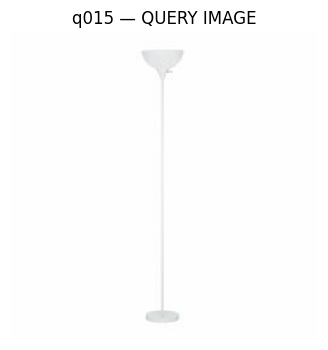

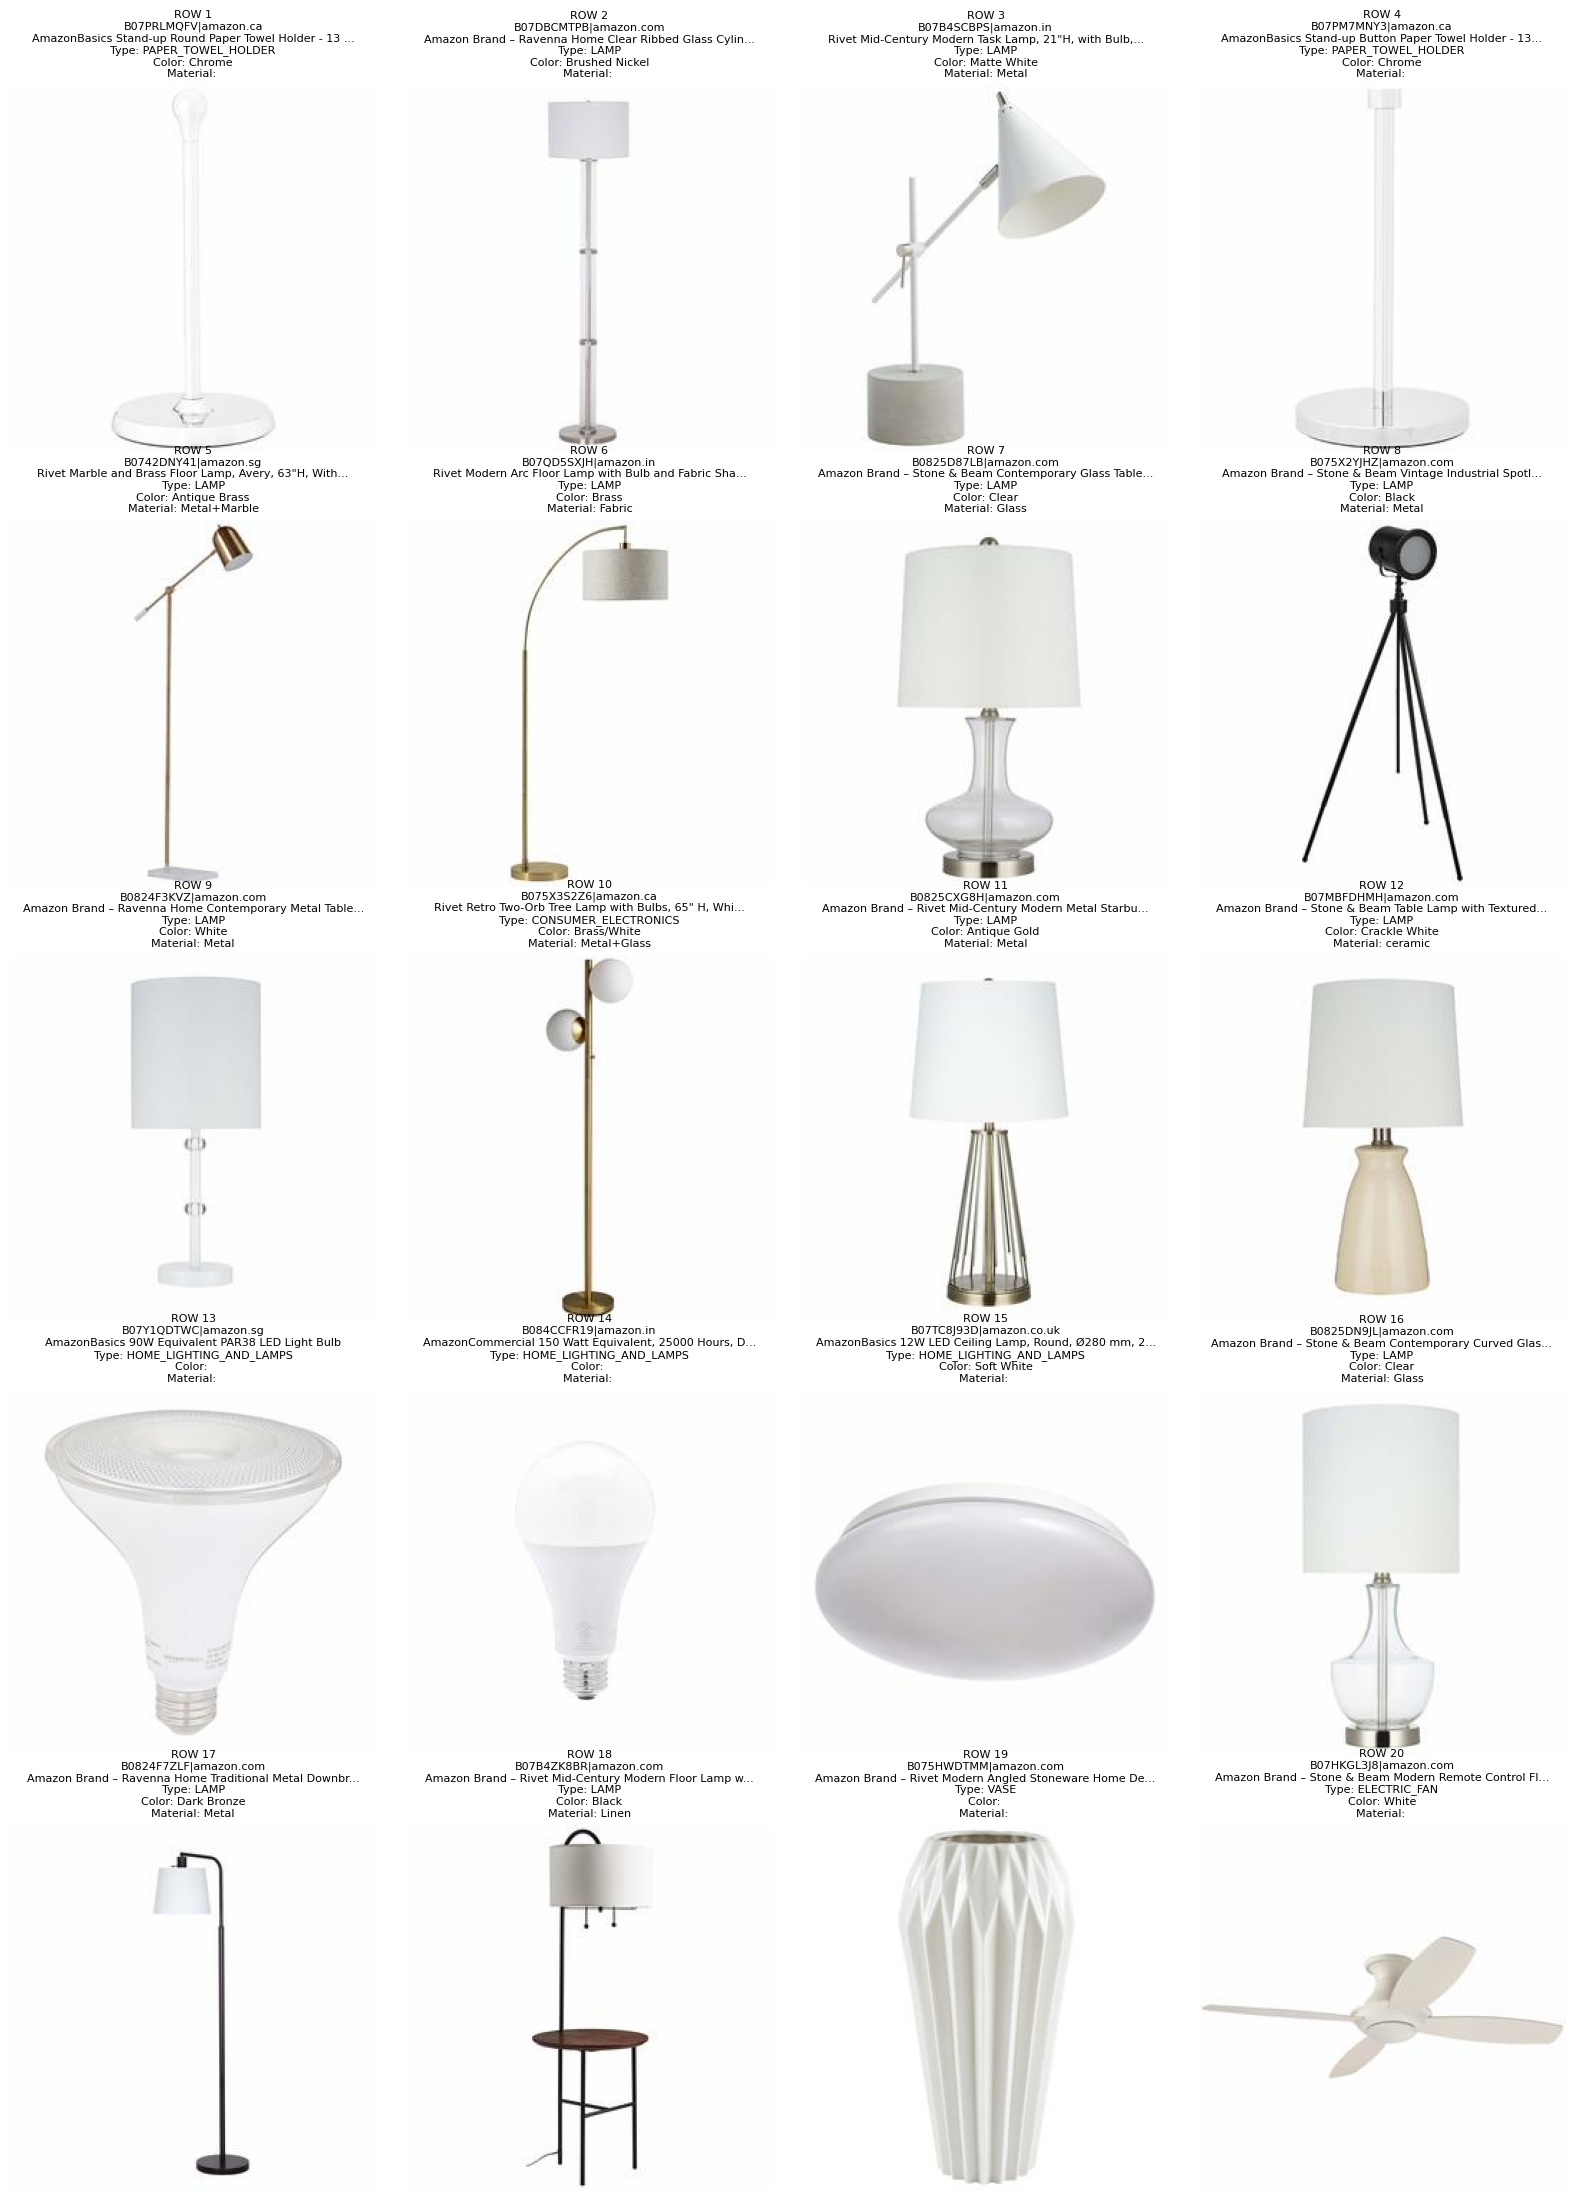

In [ ]:
show_query("q015")

In [ ]:
# Finalize the annotation CSV only when every row has a human relevance grade and reason.
from pathlib import Path
import pandas as pd, subprocess, sys

pool_path = Path('data/qrels_pool.csv')
if not pool_path.exists():
    print('Run the judgment-pool cell first.')
else:
    pool = pd.read_csv(pool_path, keep_default_na=False)
    valid_rel = pool['relevance'].astype(str).str.strip().isin({'0','1','2','0.0','1.0','2.0'})
    valid_reason = pool['reason'].astype(str).str.strip().ne('')
    if bool(valid_rel.all() and valid_reason.all()):
        subprocess.run([
            sys.executable, 'src/build_judgment_pool.py',
            '--finalize', str(pool_path),
            '--qrels_out', 'data/qrels.jsonl'
        ], check=True)
        print('Finalized human qrels -> data/qrels.jsonl')
    else:
        print(f'Annotation not complete: relevance filled {int(valid_rel.sum())}/{len(pool)}, reasons filled {int(valid_reason.sum())}/{len(pool)}.')
        print('Do not continue evaluation until all rows are manually reviewed.')


## Evaluation after annotation

Run these cells after `data/qrels.jsonl` exists. The metrics and reports are only meaningful when the qrels have been reviewed.


In [ ]:
from pathlib import Path
import subprocess, sys

if Path('data/qrels.jsonl').exists():
    subprocess.run([
        sys.executable, 'src/evaluate.py',
        '--catalog', 'data/catalog_subset.parquet',
        '--queries', 'data/queries.jsonl',
        '--qrels', 'data/qrels.jsonl',
        '--retrieval', 'outputs/retrieval_results.jsonl',
        '--reranked', 'outputs/reranked_results.jsonl',
        '--strategy_a', 'outputs/reranked_strategy_a.jsonl',
        '--out', 'reports/evaluation_metrics.csv',
        '--report', 'reports/evaluation_report.md',
        '--error_analysis', 'reports/error_analysis.md',
    ], check=True)
else:
    print('STOP: data/qrels.jsonl does not exist. Complete the human annotation checkpoint first.')


In [ ]:
from pathlib import Path
from IPython.display import Markdown, display
if Path('reports/evaluation_report.md').exists():
    display(Markdown(open('reports/evaluation_report.md', encoding='utf-8').read()))
else:
    print('Evaluation report not available yet; finalize human qrels and run evaluation first.')


In [ ]:
from pathlib import Path
if Path('reports/error_analysis.md').exists():
    display(Markdown(open('reports/error_analysis.md', encoding='utf-8').read()))
else:
    print('Error analysis not available yet; finalize human qrels and run evaluation first.')


In [ ]:
from pathlib import Path
if Path('data/qrels.jsonl').exists() and Path('reports/evaluation_metrics.csv').exists():
    !python src/tests.py --stage 4
else:
    print('Stage 4 tests skipped until human qrels and evaluation outputs exist.')


# Grounded Answer Generation and Optional QLoRA

Compare local Qwen2.5-1.5B and Qwen2.5-3B instruction models. Install the generation dependencies before this section. The optional adapter experiment uses a small formatting dataset and is disabled by default.


In [ ]:
INSTALL_GENERATION_DEPENDENCIES = False
if INSTALL_GENERATION_DEPENDENCIES:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", ".[generation]"])


In [ ]:
from pathlib import Path

required = [
    "data/catalog_subset.parquet",
    "data/queries.jsonl",
    "outputs/reranked_results.jsonl",
]

for path in required:
    print("[PASS]" if Path(path).exists() else "[MISSING]", path)

In [ ]:
# Baseline local LLM settings.
LLM_MODEL_BASELINE = "Qwen/Qwen2.5-1.5B-Instruct"
LLM_TOP_K = 8
LLM_MAX_NEW_TOKENS = 1200
LLM_REPAIR_ATTEMPTS = 2

!python src/generate_answer.py \
  --llm_backend local \
  --llm_model "$LLM_MODEL_BASELINE" \
  --load_in_4bit \
  --top_k "$LLM_TOP_K" \
  --max_new_tokens "$LLM_MAX_NEW_TOKENS" \
  --local_json_repair_attempts "$LLM_REPAIR_ATTEMPTS" \
  --debug_raw_out reports/raw_llm_debug.local_qwen15b.jsonl \
  --out outputs/final_answers.local_qwen15b.jsonl \
  --summary reports/llm_output_summary.local_qwen15b.md

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen15b.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen15b.md \
  --top_k "$LLM_TOP_K" \
  | tee reports/tests.stage5.local_qwen15b.txt


## B. Stronger reference: Qwen2.5-3B

The 3B model remains feasible on a T4 with 4-bit loading and generally follows
the schema more reliably.


In [ ]:
# Stronger local LLM reference settings.
LLM_MODEL_STRONGER = "Qwen/Qwen2.5-3B-Instruct"
LLM_TOP_K = 8
LLM_MAX_NEW_TOKENS = 1200
LLM_REPAIR_ATTEMPTS = 2

!python src/generate_answer.py \
  --llm_backend local \
  --llm_model "$LLM_MODEL_STRONGER" \
  --load_in_4bit \
  --top_k "$LLM_TOP_K" \
  --max_new_tokens "$LLM_MAX_NEW_TOKENS" \
  --local_json_repair_attempts "$LLM_REPAIR_ATTEMPTS" \
  --debug_raw_out reports/raw_llm_debug.local_qwen3b.jsonl \
  --out outputs/final_answers.local_qwen3b.jsonl \
  --summary reports/llm_output_summary.local_qwen3b.md

!python src/tests.py --stage 5 \
  --answers outputs/final_answers.local_qwen3b.jsonl \
  --llm_summary reports/llm_output_summary.local_qwen3b.md \
  --top_k "$LLM_TOP_K" \
  | tee reports/tests.stage5.local_qwen3b.txt


## Baseline comparison

Summarize accepted model outputs, repairs, and fallback counts from the generated debug records. The optional QLoRA experiment follows.


In [ ]:
import os, json, zipfile
import pandas as pd
from pathlib import Path
os.chdir(PROJECT_DIR if 'PROJECT_DIR' in globals() else os.getcwd())
print('project:', os.getcwd())


def summarize_debug(path, label):
    rows = [json.loads(l) for l in open(path, encoding='utf-8') if l.strip()]
    via = [r.get('accepted_via', '') for r in rows]
    direct = sum(v == 'direct' for v in via)
    repaired = sum(v == 'repair' for v in via)
    fallback = sum(v == 'fallback' for v in via)
    return {
        'run': label,
        'total': len(rows),
        'direct_valid': direct,
        'canonicalized_or_repaired': repaired,
        'accepted_model_outputs': direct + repaired,
        'fallback': fallback,
    }

comparison = pd.DataFrame([
    summarize_debug('reports/raw_llm_debug.local_qwen15b.jsonl', 'Qwen2.5-1.5B-Instruct'),
    summarize_debug('reports/raw_llm_debug.local_qwen3b.jsonl', 'Qwen2.5-3B-Instruct'),
])
display(comparison)
comparison.to_csv('reports/baseline_model_comparison.csv', index=False)



,run,total,direct_valid,canonicalized_or_repaired,accepted_model_outputs,fallback
0,Qwen2.5-1.5B-Instruct,20,2,0,2,18
1,Qwen2.5-3B-Instruct,20,12,0,12,8


## C. Advanced option: 1.5B QLoRA

The 3B accepted outputs become formatting targets. Training loss is applied
only to the target answer tokens. With 20 examples this demonstrates the
mechanics; it is not a large enough dataset for broad quality claims.


In [ ]:
# Optional QLoRA experiment. It is configured but disabled by default so a
# normal "Run all" does not unexpectedly start training.
RUN_OPTIONAL_LORA = False
SFT_SOURCE = "outputs/final_answers.local_qwen3b.jsonl"
LORA_BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_OUT_DIR = "adapters/qwen25-15b-json-lora"
LORA_EPOCHS = 1
LORA_LR = "2e-4"

if RUN_OPTIONAL_LORA:
    import subprocess, sys
    subprocess.run([
        sys.executable, 'src/build_answer_sft_data.py',
        '--answers', SFT_SOURCE,
        '--out', 'data/answer_sft_seed.local_qwen3b.jsonl',
        '--target_source', 'existing_or_fallback',
    ], check=True)
    subprocess.run([
        sys.executable, 'src/train_answer_lora.py',
        '--train_jsonl', 'data/answer_sft_seed.local_qwen3b.jsonl',
        '--base_model', LORA_BASE_MODEL,
        '--out_dir', LORA_OUT_DIR,
        '--num_train_epochs', str(LORA_EPOCHS),
        '--learning_rate', LORA_LR,
    ], check=True)
else:
    print('Optional QLoRA skipped. Set RUN_OPTIONAL_LORA=True to run it.')


In [ ]:
LORA_BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_OUT_DIR = "adapters/qwen25-15b-json-lora"
LLM_TOP_K = 8
LLM_MAX_NEW_TOKENS = 1200
LLM_REPAIR_ATTEMPTS = 2

if RUN_OPTIONAL_LORA:
    import subprocess, sys
    subprocess.run([
        sys.executable, 'src/generate_answer.py',
        '--llm_backend', 'local',
        '--llm_model', LORA_BASE_MODEL,
        '--adapter_path', LORA_OUT_DIR,
        '--load_in_4bit',
        '--top_k', str(LLM_TOP_K),
        '--max_new_tokens', str(LLM_MAX_NEW_TOKENS),
        '--local_json_repair_attempts', str(LLM_REPAIR_ATTEMPTS),
        '--debug_raw_out', 'reports/raw_llm_debug.local_qwen15b_lora.jsonl',
        '--out', 'outputs/final_answers.local_qwen15b_lora.jsonl',
        '--summary', 'reports/llm_output_summary.local_qwen15b_lora.md',
    ], check=True)
    subprocess.run([
        sys.executable, 'src/tests.py', '--stage', '5',
        '--answers', 'outputs/final_answers.local_qwen15b_lora.jsonl',
        '--llm_summary', 'reports/llm_output_summary.local_qwen15b_lora.md',
        '--top_k', str(LLM_TOP_K),
    ], check=True)
else:
    print('Optional LoRA generation skipped.')


In [ ]:
# Compact comparison from raw debug logs.
import json, pandas as pd
from pathlib import Path


def debug_stats(path, label):
    rows = [json.loads(l) for l in open(path, encoding='utf-8') if l.strip()]
    via = [r.get('accepted_via', '') for r in rows]
    return {
        'run': label,
        'total': len(rows),
        'direct_valid': sum(v == 'direct' for v in via),
        'canonicalized_or_repaired': sum(v == 'repair' for v in via),
        'accepted_model_outputs': sum(v in {'direct','repair'} for v in via),
        'fallback': sum(v == 'fallback' for v in via),
    }

rows = [
    debug_stats('reports/raw_llm_debug.local_qwen15b.jsonl', 'Qwen2.5-1.5B'),
    debug_stats('reports/raw_llm_debug.local_qwen3b.jsonl', 'Qwen2.5-3B'),
]
if Path('reports/raw_llm_debug.local_qwen15b_lora.jsonl').exists():
    rows.append(debug_stats('reports/raw_llm_debug.local_qwen15b_lora.jsonl', 'Qwen2.5-1.5B + LoRA'))

stage5_comparison = pd.DataFrame(rows)
display(stage5_comparison)
stage5_comparison.to_csv('reports/model_comparison_with_lora.csv', index=False)


,run,total,direct_valid,canonicalized_or_repaired,accepted_model_outputs,fallback
0,Qwen2.5-1.5B,20,2,0,2,18
1,Qwen2.5-3B,20,12,0,12,8
2,Qwen2.5-1.5B + LoRA,20,7,0,7,13
